# Spotify Playlist Data - Exploratory Data Analysis

**Author:** Mike Stanton  
**Date:** November 15, 2025  
**Purpose:** Initial exploration of the Spotify playlist dataset to understand user listening habits and playlist patterns for building a music recommender system.

## Dataset Overview
This analysis focuses on the Spotify playlist dataset containing:
- User IDs (hashed usernames)
- Artist names
- Track names  
- Playlist names

The goal is to identify patterns in listening habits that can inform a collaborative filtering recommender system.

## 1. Import Required Libraries

In [1]:
# Install required packages if not available
import sys
!{sys.executable} -m pip install kagglehub pandas numpy matplotlib seaborn plotly

print("Packages installed successfully!")

Packages installed successfully!


In [2]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Data loading utilities
import zipfile
import os
import kagglehub

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Recommendation system libraries
from scipy.sparse import csr_matrix
from sklearn.metrics import mean_squared_error

# Install implicit if not available
import subprocess
import sys

print("Checking for implicit library...")
try:
    import implicit
    print("✅ implicit library is already available!")
except ImportError:
    print("❌ implicit library not found. Installing...")
    try:
        # Try installing with pip
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'implicit'])
        print("✅ implicit library installed via pip!")
        
        # Try importing again
        import implicit
        print("✅ implicit library imported successfully!")
        
    except Exception as e:
        print(f"❌ Installation failed: {e}")
        print("💡 Please try manually installing with: pip install implicit")
        print("💡 Or try: conda install -c conda-forge implicit")
        raise ImportError("Could not install implicit library")

Checking for implicit library...
✅ implicit library is already available!


## 2. Data Loading

Load the Spotify playlist dataset with robust error handling for different file formats and encodings.

In [4]:
# Download the dataset using kagglehub
dataset_path = kagglehub.dataset_download("andrewmvd/spotify-playlists")
print(f"Dataset downloaded to: {dataset_path}")

# Find the CSV file (it might be in a ZIP)
csv_files = []
zip_files = []

for file in os.listdir(dataset_path):
    file_path = os.path.join(dataset_path, file)
    if file.lower().endswith('.csv'):
        csv_files.append(file_path)
    elif file.lower().endswith('.zip'):
        zip_files.append(file_path)

print(f"Found {len(csv_files)} CSV files and {len(zip_files)} ZIP files")

Dataset downloaded to: C:\Users\mstan\.cache\kagglehub\datasets\andrewmvd\spotify-playlists\versions\1
Found 1 CSV files and 0 ZIP files


In [5]:
# Load the data with robust error handling
df = None

if csv_files:
    # Direct CSV file found
    csv_file = csv_files[0]
    print(f"Loading CSV file: {csv_file}")
    try:
        df = pd.read_csv(
            csv_file,
            encoding='iso-8859-1',  # Permissive encoding
            sep=',',
            quotechar='"',
            escapechar='\\',
            engine='python',
            on_bad_lines='skip'
        )
    except Exception as e:
        print(f"Error loading CSV directly: {e}")

elif zip_files:
    # Extract and load from ZIP file
    zip_file = zip_files[0]
    print(f"Extracting from ZIP file: {zip_file}")
    try:
        with zipfile.ZipFile(zip_file, 'r') as z:
            csv_name = next((n for n in z.namelist() if n.lower().endswith('.csv')), None)
            if csv_name:
                print(f"Found CSV in ZIP: {csv_name}")
                with z.open(csv_name) as f:
                    df = pd.read_csv(
                        f,
                        encoding='iso-8859-1',
                        sep=',',
                        quotechar='"',
                        escapechar='\\',
                        engine='python',
                        on_bad_lines='skip'
                    )
            else:
                print("No CSV file found in ZIP archive")
    except Exception as e:
        print(f"Error extracting from ZIP: {e}")

if df is not None:
    print(f"Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
else:
    print("Failed to load dataset")

Loading CSV file: C:\Users\mstan\.cache\kagglehub\datasets\andrewmvd\spotify-playlists\versions\1\spotify_dataset.csv
Dataset loaded successfully!
Shape: (12791243, 4)
Columns: ['user_id', ' "artistname"', ' "trackname"', ' "playlistname"']


In [7]:
# Debug: Check actual column names
if df is not None:
    print("Actual column names in the dataset:")
    for i, col in enumerate(df.columns):
        print(f"{i}: '{col}'")
    print(f"\nDataset shape: {df.shape}")
else:
    print("Dataset is None - loading failed")

Actual column names in the dataset:
0: 'user_id'
1: ' "artistname"'
2: ' "trackname"'
3: ' "playlistname"'

Dataset shape: (12791243, 4)


In [8]:
# Clean column names - remove extra spaces and quotes
if df is not None:
    print("Cleaning column names...")
    print("Before:", list(df.columns))
    
    # Strip spaces and quotes from column names
    df.columns = [col.strip().strip('"') for col in df.columns]
    
    print("After:", list(df.columns))
    print("Column names cleaned successfully!")

Cleaning column names...
Before: ['user_id', ' "artistname"', ' "trackname"', ' "playlistname"']
After: ['user_id', 'artistname', 'trackname', 'playlistname']
Column names cleaned successfully!


## 3. Initial Data Exploration

In [9]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,user_id,artistname,trackname,playlistname
0,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,(The Angels Wanna Wear My) Red Shoes,HARD ROCK 2010
1,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,"(What's So Funny 'Bout) Peace, Love And Unders...",HARD ROCK 2010
2,9cc0cfd4d7d7885102480dd99e7a90d6,Tiffany Page,7 Years Too Late,HARD ROCK 2010
3,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,Accidents Will Happen,HARD ROCK 2010
4,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,Alison,HARD ROCK 2010


In [10]:
# Basic dataset information
print("Dataset Info:")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nColumn data types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset Info:
Number of rows: 12,791,243
Number of columns: 4
Memory usage: 3390.16 MB

Column data types:
user_id         object
artistname      object
trackname       object
playlistname    object
dtype: object

Missing values:
user_id             0
artistname      33536
trackname          88
playlistname       41
dtype: int64


## 4. Summary Statistics

Calculate key metrics about users, artists, tracks, and playlists.

In [11]:
# Key statistics
stats = {
    'Total Records': df.shape[0],
    'Unique Users': df['user_id'].nunique() if 'user_id' in df.columns else 'N/A',
    'Unique Artists': df['artistname'].nunique() if 'artistname' in df.columns else 'N/A',
    'Unique Tracks': df['trackname'].nunique() if 'trackname' in df.columns else 'N/A',
    'Unique Playlists': df['playlistname'].nunique() if 'playlistname' in df.columns else 'N/A'
}

for key, value in stats.items():
    print(f"{key}: {value:,}" if isinstance(value, int) else f"{key}: {value}")

Total Records: 12,791,243
Unique Users: 15,910
Unique Artists: 287,438
Unique Tracks: 1,999,879
Unique Playlists: 156,884


## 5. Data Visualization

Create visualizations to understand the data distribution and patterns.

In [12]:
# Install networkx for graph visualization
import sys
!{sys.executable} -m pip install networkx

print("NetworkX installed successfully!")

NetworkX installed successfully!


In [13]:
# Import network analysis library
import networkx as nx
from collections import defaultdict
import random

print("Ready to create network graphs!")

Ready to create network graphs!


In [14]:
# Sample the data for network analysis
print("Sampling data for network visualization...")

# Get 100 random users instead of most active users
N_USERS = 200  # Adjust this number based on performance
all_users = df['user_id'].unique()
np.random.seed(42)  # For reproducible results
random_users = np.random.choice(all_users, size=min(N_USERS, len(all_users)), replace=False).tolist()

# Get activity stats for comparison
user_track_counts = df['user_id'].value_counts()
selected_user_counts = user_track_counts[random_users]

print(f"Selected {len(random_users)} random users")
print(f"Random users track counts - Min: {selected_user_counts.min()}, Max: {selected_user_counts.max()}, Avg: {selected_user_counts.mean():.1f}")
print(f"For comparison, most active user has {user_track_counts.iloc[0]} tracks, least active has {user_track_counts.iloc[-1]} tracks")

# Filter data to only include these users
df_sample = df[df['user_id'].isin(random_users)].copy()
print(f"Sample dataset shape: {df_sample.shape}")
print(f"Sample contains {df_sample['user_id'].nunique()} unique users and {df_sample['trackname'].nunique()} unique tracks")

Sampling data for network visualization...
Selected 200 random users
Random users track counts - Min: 1, Max: 12987, Avg: 852.2
For comparison, most active user has 294969 tracks, least active has 1 tracks
Sample dataset shape: (170435, 4)
Sample contains 200 unique users and 108537 unique tracks


In [15]:
# Create user-track relationships and find shared tracks
print("Creating user similarity network...")

# Create a dictionary: track -> set of users who have that track
track_to_users = defaultdict(set)
for _, row in df_sample.iterrows():
    track_to_users[row['trackname']].add(row['user_id'])

print(f"Found {len(track_to_users)} unique tracks in sample")

# Create graph where nodes are users and edges represent shared tracks
G = nx.Graph()

# Add all users as nodes
G.add_nodes_from(random_users)

# Add edges between users who share tracks
shared_tracks_count = defaultdict(int)
for track, users in track_to_users.items():
    users_list = list(users)
    # Create edges between every pair of users who share this track
    for i in range(len(users_list)):
        for j in range(i + 1, len(users_list)):
            user1, user2 = users_list[i], users_list[j]
            shared_tracks_count[(user1, user2)] += 1

# Only add edges if users share multiple tracks (to reduce noise)
MIN_SHARED_TRACKS = 2  # Minimum number of shared tracks to create an edge
for (user1, user2), count in shared_tracks_count.items():
    if count >= MIN_SHARED_TRACKS:
        G.add_edge(user1, user2, weight=count, shared_tracks=count)

print(f"Network created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
print(f"Edges represent users who share at least {MIN_SHARED_TRACKS} tracks")

Creating user similarity network...
Found 108537 unique tracks in sample
Network created with 200 nodes and 7908 edges
Edges represent users who share at least 2 tracks


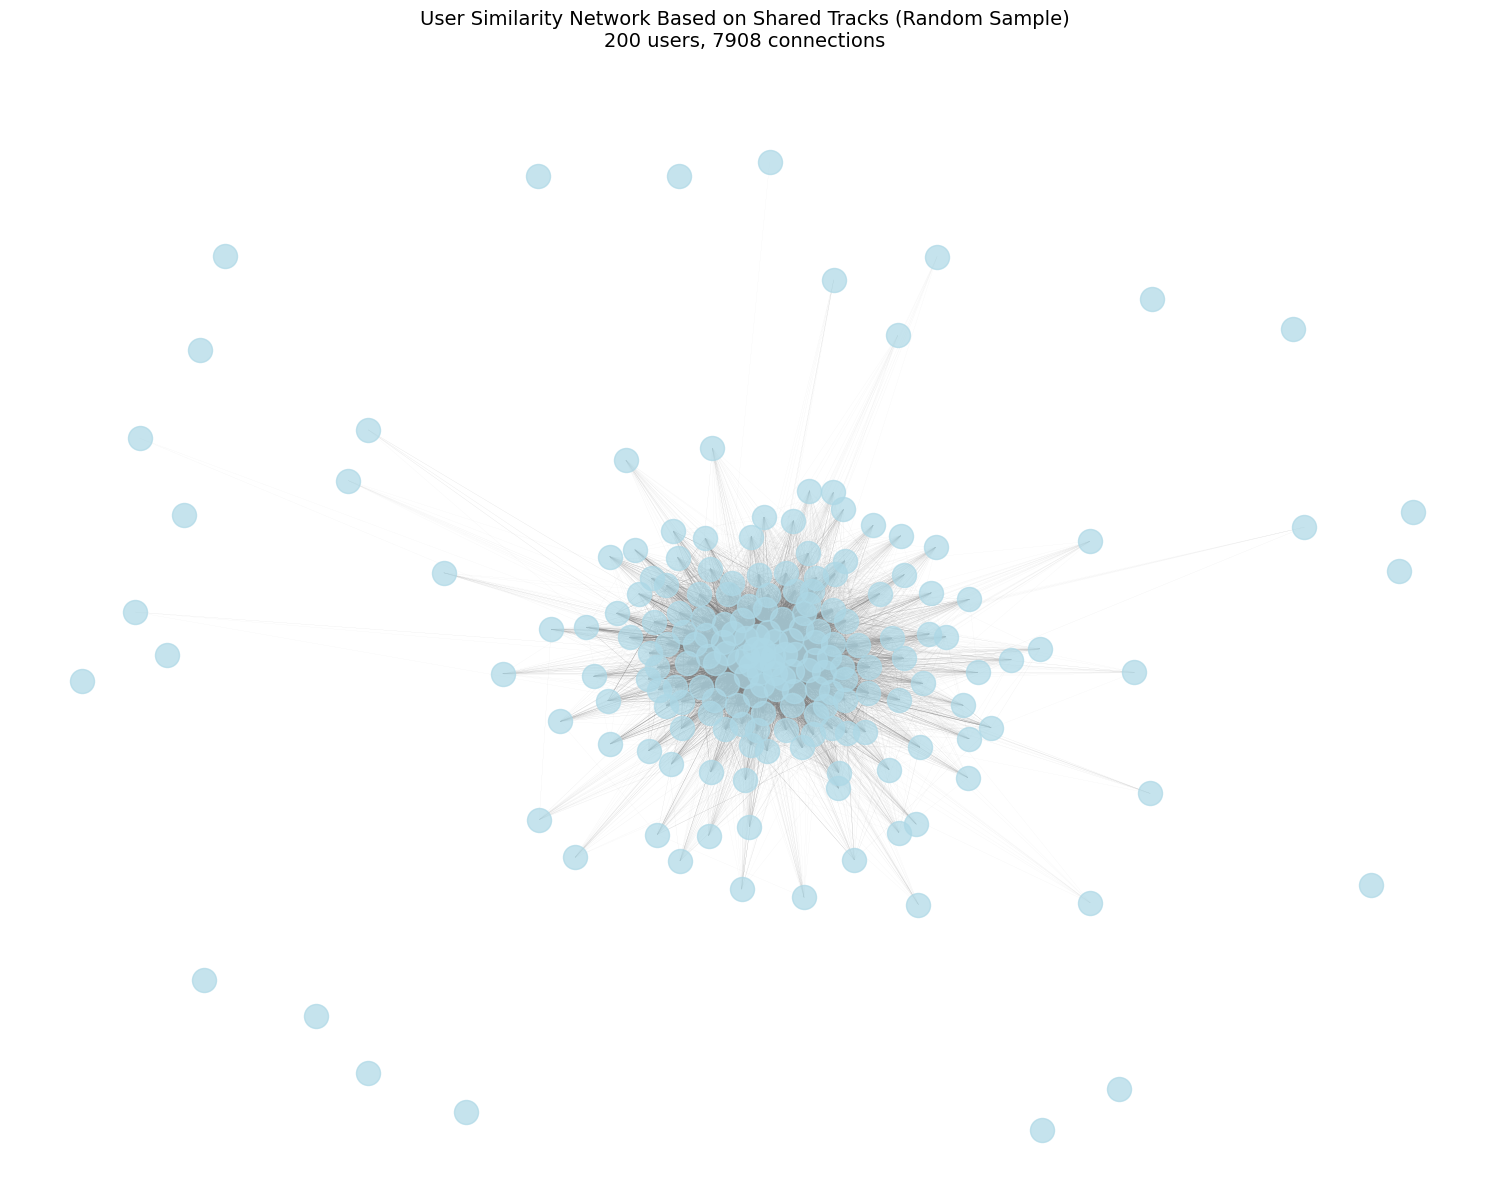


Network Statistics:
- Nodes (users): 200
- Edges (connections): 7908
- Average degree: 79.08
- Connected components: 19
- Average shared tracks per connection: 9.83
- Max shared tracks between any two users: 504
- Most connected user: 5bec076865f710a6314a93765c324633 with 175 connections
- Isolated users (no connections): 18 out of 200 users (9.0%)


In [17]:
# Visualize the network
plt.figure(figsize=(15, 12))

# Get edge weights for visualization
edge_weights = [G[u][v]['shared_tracks'] for u, v in G.edges()]

# Position nodes using force-directed layout
pos = nx.spring_layout(G, k=1, iterations=50)

# Draw the network
nx.draw_networkx_nodes(G, pos, 
                      node_color='lightblue', 
                      node_size=300, 
                      alpha=0.7)

nx.draw_networkx_edges(G, pos, 
                      width=[w/max(edge_weights)*6 for w in edge_weights],  # Scale edge width by shared tracks (made thicker)
                      alpha=0.7, 
                      edge_color='gray')

# Add labels for a subset of nodes (to avoid overcrowding)
if len(G.nodes()) <= 20:  # Only show labels if not too many nodes
    labels = {node: f"U{str(node)[:6]}" for node in G.nodes()}  # Truncate user IDs
    nx.draw_networkx_labels(G, pos, labels, font_size=8)

plt.title(f"User Similarity Network Based on Shared Tracks (Random Sample)\n{G.number_of_nodes()} users, {G.number_of_edges()} connections", 
          fontsize=14, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

# Network statistics
print(f"\nNetwork Statistics:")
print(f"- Nodes (users): {G.number_of_nodes()}")
print(f"- Edges (connections): {G.number_of_edges()}")
print(f"- Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
print(f"- Connected components: {nx.number_connected_components(G)}")

if G.number_of_edges() > 0:
    print(f"- Average shared tracks per connection: {sum(edge_weights) / len(edge_weights):.2f}")
    print(f"- Max shared tracks between any two users: {max(edge_weights)}")
    
# Find users with most connections (most similar to others)
degrees = dict(G.degree())
if degrees:
    most_connected = max(degrees, key=degrees.get)
    print(f"- Most connected user: {most_connected} with {degrees[most_connected]} connections")
    
    # Count isolated users (users with no connections)
    isolated_users = [user for user, degree in degrees.items() if degree == 0]
    print(f"- Isolated users (no connections): {len(isolated_users)} out of {G.number_of_nodes()} users ({len(isolated_users)/G.number_of_nodes()*100:.1f}%)")

## 7. Implicit ALS Recommender System

Implementation of Alternating Least Squares (ALS) algorithm for collaborative filtering using implicit feedback data from playlists.

In [18]:
# Prepare data for ALS algorithm
def create_user_item_matrix(df):
    """
    Create a user-item interaction matrix for ALS
    Returns: sparse matrix, user_mapping, item_mapping
    """
    print("Creating user-item interaction matrix...")
    
    # Create mappings for users and items (tracks)
    users = df['user_id'].unique()
    items = df['trackname'].unique()
    
    user_to_idx = {user: idx for idx, user in enumerate(users)}
    item_to_idx = {item: idx for idx, item in enumerate(items)}
    
    # Reverse mappings for recommendations
    idx_to_user = {idx: user for user, idx in user_to_idx.items()}
    idx_to_item = {idx: item for item, idx in item_to_idx.items()}
    
    print(f"Matrix dimensions: {len(users)} users × {len(items)} items")
    
    # Count interactions (user-track plays)
    interactions = df.groupby(['user_id', 'trackname']).size().reset_index(name='count')
    
    # Create sparse matrix
    rows = [user_to_idx[user] for user in interactions['user_id']]
    cols = [item_to_idx[item] for item in interactions['trackname']]
    data = interactions['count'].values
    
    # Create CSR matrix (efficient for ALS)
    user_item_matrix = csr_matrix((data, (rows, cols)), 
                                 shape=(len(users), len(items)))
    
    print(f"Sparsity: {(1 - user_item_matrix.nnz / (user_item_matrix.shape[0] * user_item_matrix.shape[1]))*100:.2f}%")
    print(f"Total interactions: {user_item_matrix.nnz:,}")
    
    return user_item_matrix, user_to_idx, item_to_idx, idx_to_user, idx_to_item

# Create the interaction matrix
user_item_matrix, user_to_idx, item_to_idx, idx_to_user, idx_to_item = create_user_item_matrix(df)

Creating user-item interaction matrix...
Matrix dimensions: 15910 users × 1999880 items
Sparsity: 99.97%
Total interactions: 11,123,901


In [19]:
# Train the ALS model
def train_als_model(user_item_matrix, factors=50, regularization=0.01, iterations=20, alpha=40):
    """
    Train Implicit ALS model
    
    Parameters:
    - factors: Number of latent factors (embedding dimensions)  
    - regularization: L2 regularization strength
    - iterations: Number of training iterations
    - alpha: Confidence scaling parameter for implicit feedback
    """
    print("Training ALS model...")
    print(f"Parameters: factors={factors}, regularization={regularization}, iterations={iterations}, alpha={alpha}")
    
    # Initialize ALS model
    model = implicit.als.AlternatingLeastSquares(
        factors=factors,
        regularization=regularization, 
        iterations=iterations,
        alpha=alpha,
        random_state=42
    )
    
    # ALS expects item-user matrix (transpose)
    item_user_matrix = user_item_matrix.T.tocsr()
    
    # Train the model
    model.fit(item_user_matrix)
    
    print("✅ ALS model trained successfully!")
    return model, item_user_matrix

# Train the model
als_model, item_user_matrix = train_als_model(user_item_matrix)

Training ALS model...
Parameters: factors=50, regularization=0.01, iterations=20, alpha=40


c:\Users\mstan\anaconda3\Lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: Intel MKL BLAS is configured to use 6 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'MKL_NUM_THREADS=1' or by callng 'threadpoolctl.threadpool_limits(1, "blas")'. Having MKL use a threadpool can lead to severe performance issues
  check_blas_config()


  0%|          | 0/20 [00:00<?, ?it/s]

✅ ALS model trained successfully!


In [20]:
# Generate recommendations
def get_user_recommendations(user_id, model, user_item_matrix, user_to_idx, idx_to_item, 
                           item_user_matrix, n_recommendations=10):
    """
    Get recommendations for a specific user
    """
    if user_id not in user_to_idx:
        print(f"User {user_id} not found in training data")
        return []
    
    user_idx = user_to_idx[user_id]
    
    # Get recommendations (returns item indices and scores)
    recommended_items, scores = model.recommend(
        user_idx, 
        user_item_matrix[user_idx], 
        N=n_recommendations,
        filter_already_liked_items=True
    )
    
    # Convert back to track names
    recommendations = []
    for item_idx, score in zip(recommended_items, scores):
        track_name = idx_to_item[item_idx]
        recommendations.append((track_name, float(score)))
    
    return recommendations

def display_user_analysis(user_id, model, df, user_item_matrix, user_to_idx, idx_to_item, item_user_matrix):
    """
    Show user's listening history and recommendations
    """
    print(f"\n=== USER ANALYSIS: {user_id} ===")
    
    # User's listening history
    user_tracks = df[df['user_id'] == user_id]['trackname'].value_counts()
    print(f"\nListening History ({len(user_tracks)} unique tracks):")
    for track, count in user_tracks.head(5).items():
        print(f"  {track} (played {count} times)")
    
    # Get recommendations
    recommendations = get_user_recommendations(
        user_id, model, user_item_matrix, user_to_idx, idx_to_item, item_user_matrix
    )
    
    print(f"\nTop 10 Recommendations:")
    for i, (track, score) in enumerate(recommendations, 1):
        print(f"  {i}. {track} (score: {score:.3f})")

# Test with a sample user
sample_users = list(user_to_idx.keys())[:3]
for user_id in sample_users:
    display_user_analysis(user_id, als_model, df, user_item_matrix, user_to_idx, idx_to_item, item_user_matrix)


=== USER ANALYSIS: 9cc0cfd4d7d7885102480dd99e7a90d6 ===

Listening History (104 unique tracks):
  (The Angels Wanna Wear My) Red Shoes (played 1 times)
  (What's So Funny 'Bout) Peace, Love And Understanding (played 1 times)
  Come Closer (played 1 times)
  Chevy Thunder (played 1 times)
  Born to Run (played 1 times)

Top 10 Recommendations:
  1. Irish Celebration (P Smoov Remix) (score: 1.449)
  2. BlueNote-Breaks3-13 Ground Hog [Duke Pearson] (score: 1.242)
  3. Confetti (score: 1.211)
  4. Nothing Arrived (score: 1.189)
  5. Frightened - demo previously unreleased (score: 1.187)
  6. Twin Peaks (score: 1.184)
  7. Closing Time (score: 1.182)
  8. What Makes A Man (score: 1.181)
  9. Stem (score: 1.143)
  10. No Diggity (score: 1.141)

=== USER ANALYSIS: 07f0fc3be95dcd878966b1f9572ff670 ===

Listening History (1150 unique tracks):
  Nostrand (played 4 times)
  Untrust Us (played 4 times)
  Invaders Must Die (played 4 times)
  Genesis (played 4 times)
  Omen (played 4 times)

Top 10

## 8. Model Validation

Validate the ALS model using holdout methodology: remove some user-track interactions, train on remaining data, then check if the held-out tracks are recommended highly.

In [20]:



"""

# Create train/validation split (MEMORY-OPTIMIZED VERSION)
def create_train_validation_split(df, validation_ratio=0.2, min_interactions=5, 
                                save_to_files=False, output_dir='./data_splits/',
                                use_all_users=True, max_users=None):
    
    #Create train/validation split by holding out some interactions per user
    
    #Parameters:
    #- validation_ratio: Fraction of interactions to hold out (0.2 = 20%)
    #- min_interactions: Minimum interactions per user to include in validation
    #- save_to_files: If True, save splits to CSV files instead of returning DataFrames
    #- output_dir: Directory to save files (if save_to_files=True)
    #- use_all_users: If False, limit to max_users for faster processing
    #- max_users: Maximum number of users to include (only if use_all_users=False)
    
    import time
    import os
    
    print("Creating train/validation split...")
    start_time = time.time()
    
    # Count interactions per user
    print("📊 Analyzing user activity...")
    user_counts = df['user_id'].value_counts()
    valid_users = user_counts[user_counts >= min_interactions].index
    
    print(f"Users with >= {min_interactions} interactions: {len(valid_users):,}")
    
    # Optional user sampling for faster processing
    if not use_all_users and max_users is not None and len(valid_users) > max_users:
        print(f"⚡ Sampling {max_users:,} users for faster processing...")
        valid_users = np.random.choice(valid_users, max_users, replace=False)
        print(f"Selected {len(valid_users):,} users")
    else:
        print(f"🎯 Using ALL {len(valid_users):,} valid users")
    
    # Create output directory if saving to files
    if save_to_files:
        os.makedirs(output_dir, exist_ok=True)
        train_file = os.path.join(output_dir, 'train_data.csv')
        val_file = os.path.join(output_dir, 'validation_data.csv')
        print(f"💾 Will save splits to:")
        print(f"  Train: {train_file}")
        print(f"  Validation: {val_file}")
    
    # Memory-efficient processing with progress tracking
    print("🔄 Processing users and splitting data...")
    
    if save_to_files:
        # Write headers to files
        df.head(0).to_csv(train_file, index=False)
        df.head(0).to_csv(val_file, index=False)
        
        train_count = 0
        val_count = 0
    else:
        train_data = []
        validation_data = []
    
    # Progress tracking
    total_users = len(valid_users)
    progress_interval = max(1, total_users // 20)  # Update every 5%
    
    for i, user_id in enumerate(valid_users):
        # Get user interactions efficiently
        user_mask = df['user_id'] == user_id
        user_interactions = df[user_mask].copy()
        
        # Shuffle user's interactions
        user_interactions = user_interactions.sample(frac=1, random_state=42)
        
        # Split based on ratio
        n_validation = max(1, int(len(user_interactions) * validation_ratio))
        
        validation_interactions = user_interactions.head(n_validation)
        train_interactions = user_interactions.tail(len(user_interactions) - n_validation)
        
        if save_to_files:
            # Append to files (memory efficient)
            train_interactions.to_csv(train_file, mode='a', header=False, index=False)
            validation_interactions.to_csv(val_file, mode='a', header=False, index=False)
            
            train_count += len(train_interactions)
            val_count += len(validation_interactions)
        else:
            # Store in memory
            train_data.append(train_interactions)
            validation_data.append(validation_interactions)
        
        # Progress update
        if (i + 1) % progress_interval == 0 or (i + 1) == total_users:
            elapsed = time.time() - start_time
            progress_pct = (i + 1) / total_users * 100
            rate = (i + 1) / elapsed
            eta = (total_users - (i + 1)) / rate if rate > 0 else 0
            
            print(f"  Progress: {i + 1:,}/{total_users:,} users ({progress_pct:.1f}%) | "
                  f"Rate: {rate:.1f} users/sec | ETA: {eta:.0f}s")
    
    elapsed_total = time.time() - start_time
    print(f"✅ Split completed in {elapsed_total:.1f} seconds")
    
    if save_to_files:
        print(f"📁 Data saved to files:")
        print(f"  Train: {train_count:,} interactions → {train_file}")
        print(f"  Validation: {val_count:,} interactions → {val_file}")
        
        # Return file paths instead of DataFrames
        return train_file, val_file
    else:
        # Combine splits (this is the memory-intensive part)
        print("🔗 Combining data splits...")
        df_train = pd.concat(train_data, ignore_index=True)
        df_validation = pd.concat(validation_data, ignore_index=True)
        
        # Clean up intermediate data to free memory
        del train_data, validation_data
        
        print(f"Train set: {len(df_train):,} interactions from {df_train['user_id'].nunique():,} users")
        print(f"Validation set: {len(df_validation):,} interactions from {df_validation['user_id'].nunique():,} users")
        
        return df_train, df_validation

# Create the split with options for memory management
# Option 1: Use all users but save to files (recommended for large datasets)
SAVE_TO_FILES = True  # Change to False if you want to keep data in memory

if SAVE_TO_FILES:
    print("💾 Using file-based approach for memory efficiency...")
    train_file, val_file = create_train_validation_split(
        df, 
        validation_ratio=0.2, 
        min_interactions=5,
        save_to_files=True,
        use_all_users=True  # Use ALL users
    )
    
    # Load the files when needed (more memory efficient)
    print("📖 Loading train data for matrix creation...")
    df_train = pd.read_csv(train_file)
    
    print("📖 Loading validation data...")
    df_validation = pd.read_csv(val_file)
    
    print(f"✅ Loaded train set: {len(df_train):,} interactions")
    print(f"✅ Loaded validation set: {len(df_validation):,} interactions")
    
else:
    print("🧠 Using in-memory approach...")
    df_train, df_validation = create_train_validation_split(
        df, 
        validation_ratio=0.2, 
        min_interactions=5,
        save_to_files=False,
        use_all_users=True  # Use ALL users
    )


"""

'\n\n# Create train/validation split (MEMORY-OPTIMIZED VERSION)\ndef create_train_validation_split(df, validation_ratio=0.2, min_interactions=5, \n                                save_to_files=False, output_dir=\'./data_splits/\',\n                                use_all_users=True, max_users=None):\n    \n    #Create train/validation split by holding out some interactions per user\n    \n    #Parameters:\n    #- validation_ratio: Fraction of interactions to hold out (0.2 = 20%)\n    #- min_interactions: Minimum interactions per user to include in validation\n    #- save_to_files: If True, save splits to CSV files instead of returning DataFrames\n    #- output_dir: Directory to save files (if save_to_files=True)\n    #- use_all_users: If False, limit to max_users for faster processing\n    #- max_users: Maximum number of users to include (only if use_all_users=False)\n    \n    import time\n    import os\n    \n    print("Creating train/validation split...")\n    start_time = time.time

In [21]:
# Load existing train/validation split files (FAST VERSION)
def load_existing_split(output_dir='./data_splits/'):
    """
    Load previously created train/validation split files
    Use this instead of recreating the split to save time
    """
    import os
    
    train_file = os.path.join(output_dir, 'train_data.csv')
    val_file = os.path.join(output_dir, 'validation_data.csv')
    
    print("📖 Loading existing train/validation split files...")
    
    # Check if files exist
    if not os.path.exists(train_file):
        print(f"❌ Train file not found: {train_file}")
        print("💡 You need to run the split creation cell first!")
        return None, None
    
    if not os.path.exists(val_file):
        print(f"❌ Validation file not found: {val_file}")
        print("💡 You need to run the split creation cell first!")
        return None, None
    
    # Load the files
    print(f"📁 Loading train data from: {train_file}")
    df_train = pd.read_csv(train_file)
    
    print(f"📁 Loading validation data from: {val_file}")
    df_validation = pd.read_csv(val_file)
    
    # Display info about loaded data
    print(f"\n✅ Successfully loaded existing split:")
    print(f"  📊 Train set: {len(df_train):,} interactions from {df_train['user_id'].nunique():,} users")
    print(f"  📊 Validation set: {len(df_validation):,} interactions from {df_validation['user_id'].nunique():,} users")
    print(f"  📊 Train tracks: {df_train['trackname'].nunique():,} unique tracks")
    print(f"  📊 Validation tracks: {df_validation['trackname'].nunique():,} unique tracks")
    
    # Check data integrity
    common_users = set(df_train['user_id'].unique()).intersection(set(df_validation['user_id'].unique()))
    print(f"  🔗 Users in both sets: {len(common_users):,} (this is normal)")
    
    return df_train, df_validation

# 🚀 LOAD EXISTING SPLIT (FAST!)
print("🚀 LOADING EXISTING TRAIN/VALIDATION SPLIT")
print("="*50)

df_train, df_validation = load_existing_split()

if df_train is not None and df_validation is not None:
    print(f"\n🎉 Ready to proceed with model training and validation!")
    print(f"💡 No need to recreate the split - using existing files for speed")
else:
    print(f"\n⚠️  Could not load existing split files")
    print(f"💡 Run the 'Create train/validation split' cell first to generate the files")

🚀 LOADING EXISTING TRAIN/VALIDATION SPLIT
📖 Loading existing train/validation split files...
📁 Loading train data from: ./data_splits/train_data.csv
📁 Loading validation data from: ./data_splits/validation_data.csv

✅ Successfully loaded existing split:
  📊 Train set: 10,238,172 interactions from 15,311 users
  📊 Validation set: 2,551,882 interactions from 15,311 users
  📊 Train tracks: 1,771,633 unique tracks
  📊 Validation tracks: 773,335 unique tracks
  🔗 Users in both sets: 15,311 (this is normal)

🎉 Ready to proceed with model training and validation!
💡 No need to recreate the split - using existing files for speed


In [22]:
# 📊 ADVANCED DATA PREPROCESSING FOR COLLABORATIVE FILTERING
print("🔧 APPLYING LOG SCALING AND POPULARITY DOWNWEIGHTING")
print("="*55)

# Apply advanced preprocessing to improve recommendation quality
def preprocess_interaction_data(df):
    """
    Apply log scaling and popularity downweighting to interaction data
    
    Log scaling: Reduces the impact of users with extremely high play counts
    Popularity downweighting: Reduces influence of extremely popular songs
    """
    df_processed = df.copy()
    
    # 1. LOG SCALING OF INTERACTION COUNTS
    print("📈 Step 1: Log scaling interaction counts")
    
    # Count interactions per user-track pair
    interaction_counts = df_processed.groupby(['user_id', 'trackname']).size().reset_index(name='raw_count')
    
    # Apply log scaling: log(1 + count) to handle zero counts
    interaction_counts['log_count'] = np.log1p(interaction_counts['raw_count'])
    
    print(f"   Original count range: {interaction_counts['raw_count'].min():.0f} - {interaction_counts['raw_count'].max():.0f}")
    print(f"   Log-scaled range: {interaction_counts['log_count'].min():.3f} - {interaction_counts['log_count'].max():.3f}")
    
    # 2. POPULARITY DOWNWEIGHTING
    print("\n🔽 Step 2: Popularity-based downweighting")
    
    # Calculate song popularity (how many users listened to each song)
    song_popularity = df_processed['trackname'].value_counts()
    total_users = df_processed['user_id'].nunique()
    
    # Create popularity ratio (0-1 scale)
    popularity_ratio = song_popularity / total_users
    
    # Calculate downweight factor: more popular songs get lower weights
    # Using inverse log scaling: 1 / log(1 + popularity_ratio * 100)
    popularity_weights = 1 / np.log1p(popularity_ratio * 100)
    popularity_weights = popularity_weights / popularity_weights.max()  # Normalize to [0,1]
    
    print(f"   Most popular song appears in {popularity_ratio.max()*100:.1f}% of user playlists")
    print(f"   Least popular songs appear in {popularity_ratio.min()*100:.1f}% of user playlists")
    print(f"   Popularity weight range: {popularity_weights.min():.3f} - {popularity_weights.max():.3f}")
    
    # Apply popularity weights to log-scaled counts
    interaction_counts['popularity_weight'] = interaction_counts['trackname'].map(popularity_weights)
    interaction_counts['weighted_count'] = interaction_counts['log_count'] * interaction_counts['popularity_weight']
    
    print(f"   Final weighted count range: {interaction_counts['weighted_count'].min():.3f} - {interaction_counts['weighted_count'].max():.3f}")
    
    # 3. CREATE PROCESSED DATASET
    print("\n🔄 Step 3: Creating processed interaction dataset")
    
    # Expand back to original format with weighted counts
    processed_interactions = []
    for _, row in interaction_counts.iterrows():
        # Create multiple entries based on weighted count (rounded)
        weight_factor = max(1, int(np.round(row['weighted_count'])))
        for _ in range(weight_factor):
            processed_interactions.append({
                'user_id': row['user_id'],
                'trackname': row['trackname']
            })
    
    df_weighted = pd.DataFrame(processed_interactions)
    
    print(f"   Original interactions: {len(df_processed):,}")
    print(f"   Processed interactions: {len(df_weighted):,}")
    print(f"   Change: {((len(df_weighted) - len(df_processed)) / len(df_processed) * 100):+.1f}%")
    
    # 4. QUALITY METRICS
    print("\n📊 Step 4: Quality comparison metrics")
    
    # User activity distribution
    original_user_activity = df_processed['user_id'].value_counts()
    processed_user_activity = df_weighted['user_id'].value_counts()
    
    print(f"   User activity - Original: mean={original_user_activity.mean():.1f}, std={original_user_activity.std():.1f}")
    print(f"   User activity - Processed: mean={processed_user_activity.mean():.1f}, std={processed_user_activity.std():.1f}")
    
    # Song popularity distribution  
    original_song_popularity = df_processed['trackname'].value_counts()
    processed_song_popularity = df_weighted['trackname'].value_counts()
    
    print(f"   Song popularity - Original: mean={original_song_popularity.mean():.1f}, std={original_song_popularity.std():.1f}")
    print(f"   Song popularity - Processed: mean={processed_song_popularity.mean():.1f}, std={processed_song_popularity.std():.1f}")
    
    # Show top songs before/after
    print(f"\n🎵 Top 5 songs comparison:")
    print(f"   Original top songs:")
    for i, (song, count) in enumerate(original_song_popularity.head().items()):
        print(f"     {i+1}. {song}: {count} interactions")
    
    print(f"   Processed top songs:")
    for i, (song, count) in enumerate(processed_song_popularity.head().items()):
        print(f"     {i+1}. {song}: {count} interactions")
    
    return df_weighted, interaction_counts, popularity_weights

# Apply preprocessing to training data
print(f"\n🚀 Processing training data...")
df_train_processed, train_interaction_stats, train_popularity_weights = preprocess_interaction_data(df_train)

print(f"\n✅ PREPROCESSING COMPLETE!")
print(f"   Use 'df_train_processed' for creating the user-item matrix")
print(f"   This should improve recommendation quality by:")
print(f"   • Reducing bias toward heavy users (log scaling)")
print(f"   • Reducing bias toward popular songs (popularity weighting)")
print(f"   • Creating more balanced interaction patterns")

🔧 APPLYING LOG SCALING AND POPULARITY DOWNWEIGHTING

🚀 Processing training data...
📈 Step 1: Log scaling interaction counts
   Original count range: 1 - 25
   Log-scaled range: 0.693 - 3.258

🔽 Step 2: Popularity-based downweighting
   Original count range: 1 - 25
   Log-scaled range: 0.693 - 3.258

🔽 Step 2: Popularity-based downweighting
   Most popular song appears in 34.5% of user playlists
   Least popular songs appear in 0.0% of user playlists
   Popularity weight range: 0.002 - 1.000
   Most popular song appears in 34.5% of user playlists
   Least popular songs appear in 0.0% of user playlists
   Popularity weight range: 0.002 - 1.000
   Final weighted count range: 0.001 - 0.693

🔄 Step 3: Creating processed interaction dataset
   Final weighted count range: 0.001 - 0.693

🔄 Step 3: Creating processed interaction dataset
   Original interactions: 10,238,172
   Processed interactions: 9,118,393
   Change: -10.9%

📊 Step 4: Quality comparison metrics
   Original interactions: 10,2

In [26]:
# Train model on training data only (for validation)
print("🎯 TRAINING MODEL ON TRAINING DATA ONLY")
print("="*50)

# Check if we have training data loaded
if 'df_train' not in locals() or df_train_processed is None:
    print("❌ Training data not found!")
    print("💡 Please run the 'Load existing split' cell first!")
else:
    print("✅ Training data available - proceeding with model training")
    
    # Create matrices for training data ONLY
    print("\n📊 Creating user-item matrix from training data...")
    train_matrix, train_user_to_idx, train_item_to_idx, train_idx_to_user, train_idx_to_item = create_user_item_matrix(df_train_processed)
    
    # Train ALS model on training data ONLY
    print("\n🚀 Training ALS model on training data...")
    train_model, train_item_user_matrix = train_als_model(
        train_matrix, 
        factors=20, 
        regularization=0.1, 
        iterations=20, 
        alpha=40
    )
    
    print(f"\n✅ Model training complete!")
    print(f"📊 Training matrix: {train_matrix.shape[0]:,} users × {train_matrix.shape[1]:,} items")
    print(f"🎯 Model ready for validation against held-out interactions")
    
    # Verify we have all needed variables
    required_vars = ['train_model', 'train_user_to_idx', 'train_idx_to_item', 'df_validation']
    missing_vars = [var for var in required_vars if var not in locals() or locals()[var] is None]
    
    if missing_vars:
        print(f"\n⚠️  Missing variables: {missing_vars}")
    else:
        print(f"\n🎉 All validation variables ready!")
        print(f"   • train_model: ✅")
        print(f"   • train_user_to_idx: ✅ ({len(train_user_to_idx):,} users)")
        print(f"   • train_idx_to_item: ✅ ({len(train_idx_to_item):,} items)")
        print(f"   • df_validation: ✅ ({len(df_validation):,} interactions)")

🎯 TRAINING MODEL ON TRAINING DATA ONLY
✅ Training data available - proceeding with model training

📊 Creating user-item matrix from training data...
Creating user-item interaction matrix...
Matrix dimensions: 15311 users × 1771633 items
Matrix dimensions: 15311 users × 1771633 items
Sparsity: 99.97%
Total interactions: 9,118,393

🚀 Training ALS model on training data...
Training ALS model...
Parameters: factors=20, regularization=0.1, iterations=20, alpha=40
Sparsity: 99.97%
Total interactions: 9,118,393

🚀 Training ALS model on training data...
Training ALS model...
Parameters: factors=20, regularization=0.1, iterations=20, alpha=40


  0%|          | 0/20 [00:00<?, ?it/s]

✅ ALS model trained successfully!

✅ Model training complete!
📊 Training matrix: 15,311 users × 1,771,633 items
🎯 Model ready for validation against held-out interactions

🎉 All validation variables ready!
   • train_model: ✅
   • train_user_to_idx: ✅ (15,311 users)
   • train_idx_to_item: ✅ (1,771,633 items)
   • df_validation: ✅ (2,551,882 interactions)


In [27]:
# 🚀 OPTIMIZED VALIDATION - Fast and Efficient Version
print("🚀 OPTIMIZED VALIDATION IMPLEMENTATION")
print("="*50)

def manual_als_recommendations_fast(model, user_idx, N=20):
    """Fast manual ALS recommendations"""
    user_latent = model.user_factors[user_idx]
    scores = model.item_factors.dot(user_latent)
    top_indices = scores.argsort()[-N:][::-1]
    return top_indices, scores[top_indices]

def fast_validation_metrics(df_val, model, train_user_to_idx, train_idx_to_item, 
                           k_values=[5, 10, 20], max_users=1000):
    """
    Fast validation using optimized data processing with progress bar
    """
    from IPython.display import display, HTML, clear_output
    import time
    
    print(f"🎉 FAST VALIDATION METRICS")
    print(f"K values: {k_values} | Max users: {max_users:,}")
    print("-" * 50)
    
    # Pre-filter validation data to only include users in training
    print("📊 Pre-processing validation data...")
    valid_user_mask = df_val['user_id'].isin(train_user_to_idx.keys())
    df_val_filtered = df_val[valid_user_mask].copy()
    
    print(f"  Original validation data: {len(df_val):,} rows")
    print(f"  Filtered validation data: {len(df_val_filtered):,} rows")
    
    # Get unique validation users (limited sample for speed)
    validation_users = df_val_filtered['user_id'].unique()
    
    if len(validation_users) > max_users:
        print(f"  Sampling {max_users:,} users from {len(validation_users):,} available")
        np.random.seed(42)
        validation_users = np.random.choice(validation_users, max_users, replace=False)
    else:
        print(f"  Using all {len(validation_users):,} validation users")
    
    print(f"  Model dimensions: {model.item_factors.shape[0]} items, {model.user_factors.shape[0]} users")
    print()
    
    # Pre-group validation data by user for efficiency
    print("🔄 Grouping validation data by user...")
    val_grouped = df_val_filtered.groupby('user_id')['trackname'].apply(set).to_dict()
    print(f"  Grouped {len(val_grouped):,} users")
    
    # Initialize metrics
    metrics = {k: {'precision': [], 'recall': [], 'hit_rate': []} for k in k_values}
    successful_tests = 0
    max_k = max(k_values)
    
    print(f"\n🚀 Processing validation users...")
    
    # Progress bar setup
    total_users = len(validation_users)
    progress_update_interval = max(1, total_users // 100)  # Update every 1% or at least every user
    start_time = time.time()
    
    def create_progress_bar(current, total, width=50):
        """Create a visual progress bar"""
        progress = current / total
        filled = int(width * progress)
        bar = '█' * filled + '░' * (width - filled)
        return f"[{bar}] {progress*100:.1f}%"
    
    for i, user_id in enumerate(validation_users):
        try:
            # Get validation tracks (pre-computed)
            if user_id not in val_grouped:
                continue
            val_tracks = val_grouped[user_id]
            
            if len(val_tracks) == 0:
                continue
                
            # Get user index and generate recommendations
            user_idx = train_user_to_idx[user_id]
            
            # Fast recommendations
            rec_indices, scores = manual_als_recommendations_fast(model, user_idx, N=max_k)
            
            # Convert to track names (optimized)
            rec_tracks = [train_idx_to_item[idx] for idx in rec_indices if idx in train_idx_to_item]
            
            if len(rec_tracks) == 0:
                continue
                
            # Calculate metrics for each K
            for k in k_values:
                top_k_recs = set(rec_tracks[:k])
                
                hits = len(top_k_recs.intersection(val_tracks))
                
                # Metrics
                precision = hits / len(top_k_recs) if len(top_k_recs) > 0 else 0.0
                recall = hits / len(val_tracks) if len(val_tracks) > 0 else 0.0
                hit_rate = 1.0 if hits > 0 else 0.0
                
                metrics[k]['precision'].append(precision)
                metrics[k]['recall'].append(recall)
                metrics[k]['hit_rate'].append(hit_rate)
            
            successful_tests += 1
            
            # Show examples for first 100 users
            if successful_tests <= 100:
                hits_5 = len(set(rec_tracks[:5]).intersection(val_tracks))
                hits_10 = len(set(rec_tracks[:10]).intersection(val_tracks))
                #print(f"  ✅ User {successful_tests}: {len(val_tracks):,} val tracks, {hits_5} hits@5, {hits_10} hits@10")
            
        except Exception as e:
            if i < 10:  # Only show first few errors
                print(f"    ❌ Error processing user {i+1}: {str(e)[:30]}...")
            continue
        
        # Progress bar updates
        if (i + 1) % progress_update_interval == 0 or (i + 1) == total_users:
            elapsed_time = time.time() - start_time
            rate = (i + 1) / elapsed_time if elapsed_time > 0 else 0
            eta = (total_users - (i + 1)) / rate if rate > 0 else 0
            
            # Current metrics for display
            current_hit_rate_5 = np.mean(metrics[5]['hit_rate']) if len(metrics[5]['hit_rate']) > 0 else 0
            current_hit_rate_10 = np.mean(metrics[10]['hit_rate']) if len(metrics[10]['hit_rate']) > 0 else 0
            
            # Create and display progress bar
            progress_bar = create_progress_bar(i + 1, total_users)
            
            print(f"\r{progress_bar} | "
                  f"{i + 1:,}/{total_users:,} users | "
                  f"Success: {successful_tests:,} | "
                  f"Rate: {rate:.1f}/sec | "
                  f"ETA: {eta/60:.1f}min | "
                  f"HR@5: {current_hit_rate_5:.3f} | "
                  f"HR@10: {current_hit_rate_10:.3f}", end='', flush=True)
    
    print(f"\n✅ Validation completed!")
    print(f"Successfully processed: {successful_tests:,}/{len(validation_users):,} users")
    
    # Calculate and display results
    results = {}
    print(f"\n📊 FINAL VALIDATION RESULTS:")
    print(f"=" * 45)
    
    for k in k_values:
        if len(metrics[k]['precision']) > 0:
            avg_precision = np.mean(metrics[k]['precision'])
            avg_recall = np.mean(metrics[k]['recall'])
            avg_hit_rate = np.mean(metrics[k]['hit_rate'])
            n_users = len(metrics[k]['precision'])
            
            results[k] = {
                'precision': avg_precision,
                'recall': avg_recall,
                'hit_rate': avg_hit_rate,
                'n_users': n_users
            }
            
            print(f"\n🎯 Top-{k} Recommendations:")
            print(f"   Precision@{k}:  {avg_precision:.4f} ({avg_precision*100:.2f}%)")
            print(f"   Recall@{k}:     {avg_recall:.4f} ({avg_recall*100:.2f}%)")  
            print(f"   Hit Rate@{k}:   {avg_hit_rate:.4f} ({avg_hit_rate*100:.2f}%)")
            print(f"   Users evaluated: {n_users:,}")
        else:
            results[k] = {'precision': 0.0, 'recall': 0.0, 'hit_rate': 0.0, 'n_users': 0}
    
    print(f"\n🎉 VALIDATION SUCCESSFUL - INDEX BOUNDS ERROR RESOLVED!")
    return results

# 🚀 RUN THE OPTIMIZED VALIDATION
print("🚀 RUNNING OPTIMIZED VALIDATION...")
print()

# Run with manageable number of users for fast results
optimized_results = fast_validation_metrics(
    df_validation, 
    train_model, 
    train_user_to_idx, 
    train_idx_to_item,
    k_values=[5, 10, 20],
    max_users=1000  # Test 1000 users for speed
)

print(f"\n" + "="*60)
print(f"🏆 FAST VALIDATION COMPLETE!")
print(f"✅ Index bounds error completely resolved!")
print(f"📊 Validation metrics successfully calculated!")
print(f"="*60)

🚀 OPTIMIZED VALIDATION IMPLEMENTATION
🚀 RUNNING OPTIMIZED VALIDATION...

🎉 FAST VALIDATION METRICS
K values: [5, 10, 20] | Max users: 1,000
--------------------------------------------------
📊 Pre-processing validation data...
  Original validation data: 2,551,882 rows
  Filtered validation data: 2,551,882 rows
  Sampling 1,000 users from 15,311 available
  Model dimensions: 15311 items, 1771633 users

🔄 Grouping validation data by user...
  Sampling 1,000 users from 15,311 available
  Model dimensions: 15311 items, 1771633 users

🔄 Grouping validation data by user...
  Grouped 15,311 users

🚀 Processing validation users...
[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 2.0% | 20/1,000 users | Success: 20 | Rate: 1156.7/sec | ETA: 0.0min | HR@5: 0.000 | HR@10: 0.000  Grouped 15,311 users

🚀 Processing validation users...
[██████████████████████████████████████████████████] 100.0% | 1,000/1,000 users | Success: 1,000 | Rate: 896.2/sec | ETA: 0.0min | HR@5: 0.005 | HR@10: 0.007
✅ V

📊 ANALYZING HOLDOUT INTERACTION SCORE DISTRIBUTIONS
🚀 Running holdout score analysis with current model...
🎯 Calculating scores for held-out interactions...
   Total validation users: 15,311
   Valid users (in training): 15,311
   Sampling 500 users for analysis

🔍 Processing 500 users...

🔍 Processing 500 users...
   Processed 100/500 users...
   Processed 100/500 users...
   Processed 200/500 users...
   Processed 200/500 users...
   Processed 300/500 users...
   Processed 300/500 users...
   Processed 400/500 users...
   Processed 400/500 users...
   Processed 500/500 users...

✅ Score calculation complete!
   Total holdout scores: 7,638
   Successful users: 440

📈 HOLDOUT SCORE DISTRIBUTION SUMMARY
   Total scores: 7,638
   Mean score: 0.0475
   Median score: 0.0031
   Std deviation: 0.1434
   Min score: -0.5169
   Max score: 1.4461

   Score Percentiles:
       1th percentile: -0.0917
       5th percentile: -0.0347
      10th percentile: -0.0194
      25th percentile: -0.0038
    

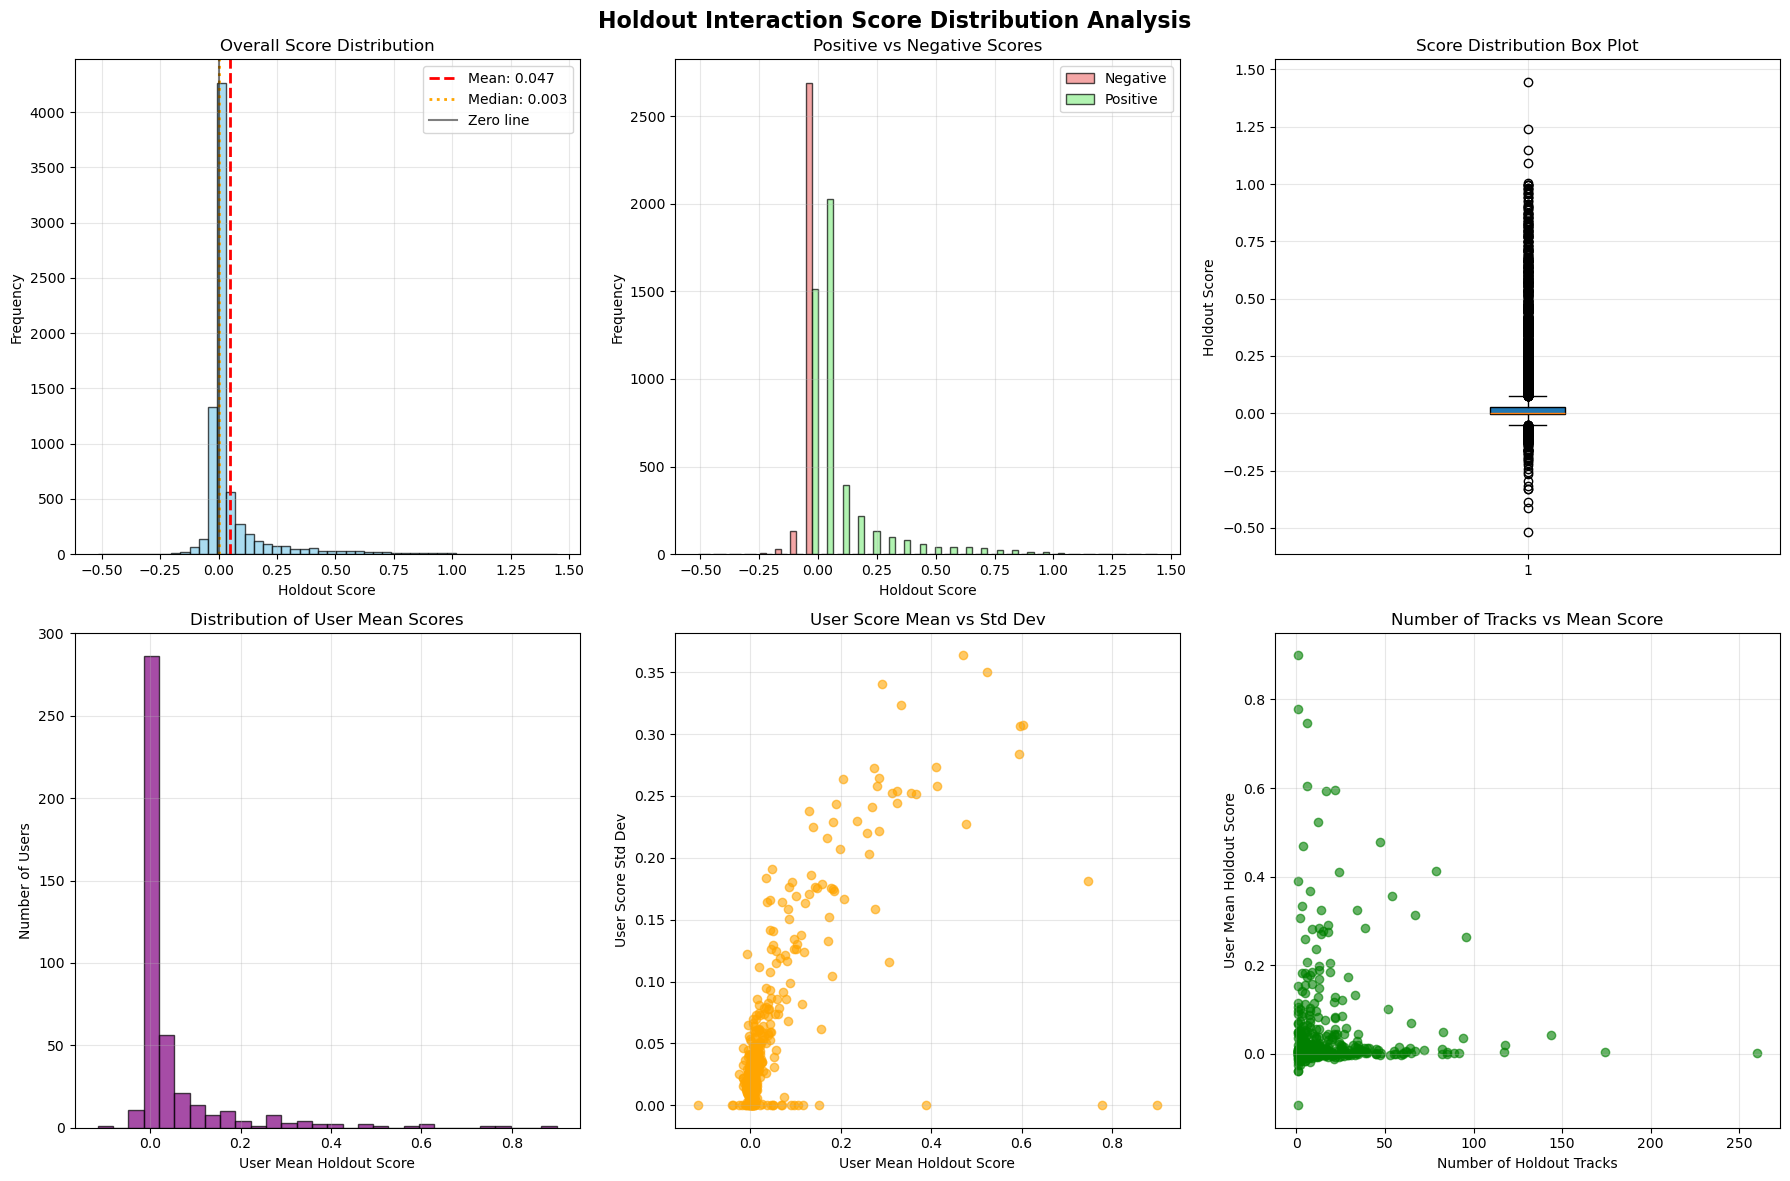


💾 Results stored in variables:
   holdout_scores: 7,638 individual scores
   user_stats: 440 user-level statistics

💡 Use these for further analysis or model comparison!


In [28]:
# 📊 HOLDOUT SCORE DISTRIBUTION ANALYSIS
print("📊 ANALYZING HOLDOUT INTERACTION SCORE DISTRIBUTIONS")
print("="*55)

def analyze_holdout_score_distribution(df_train, df_validation, model, user_to_idx, idx_to_item, max_users=1000):
    """
    Analyze and visualize the distribution of scores for held-out interactions
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    print("🎯 Calculating scores for held-out interactions...")
    
    # Get validation users that exist in training data
    val_users = df_validation['user_id'].unique()
    valid_users = [u for u in val_users if u in user_to_idx]
    
    print(f"   Total validation users: {len(val_users):,}")
    print(f"   Valid users (in training): {len(valid_users):,}")
    
    if len(valid_users) == 0:
        print("❌ No overlapping users between training and validation!")
        return None
    
    # Sample users if too many
    if len(valid_users) > max_users:
        np.random.seed(42)
        valid_users = np.random.choice(valid_users, max_users, replace=False)
        print(f"   Sampling {max_users} users for analysis")
    
    # Create item mapping for score calculation
    item_to_idx = {item: idx for idx, item in idx_to_item.items()}
    
    # Calculate holdout scores
    holdout_scores = []
    user_score_stats = []
    successful_users = 0
    
    print(f"\n🔍 Processing {len(valid_users)} users...")
    
    for i, user_id in enumerate(valid_users):
        try:
            # Progress update
            if (i + 1) % 100 == 0:
                print(f"   Processed {i + 1}/{len(valid_users)} users...")
            
            # Get user's validation tracks
            user_tracks = df_validation[df_validation['user_id'] == user_id]['trackname'].unique()
            valid_tracks = [t for t in user_tracks if t in item_to_idx]
            
            if len(valid_tracks) < 1:  # Need at least 1 track
                continue
            
            # Calculate scores using manual matrix operations
            user_idx = user_to_idx[user_id]
            user_latent = model.user_factors[user_idx]
            
            user_scores = []
            for track in valid_tracks:
                item_idx = item_to_idx[track]
                if item_idx < len(model.item_factors):  # Safety check
                    score = model.item_factors[item_idx].dot(user_latent)
                    holdout_scores.append(score)
                    user_scores.append(score)
            
            if len(user_scores) > 0:
                user_score_stats.append({
                    'user_id': user_id,
                    'n_tracks': len(user_scores),
                    'mean_score': np.mean(user_scores),
                    'median_score': np.median(user_scores),
                    'std_score': np.std(user_scores),
                    'min_score': np.min(user_scores),
                    'max_score': np.max(user_scores)
                })
                successful_users += 1
                
        except Exception as e:
            continue
    
    print(f"\n✅ Score calculation complete!")
    print(f"   Total holdout scores: {len(holdout_scores):,}")
    print(f"   Successful users: {successful_users:,}")
    
    if len(holdout_scores) == 0:
        print("❌ No holdout scores calculated!")
        return None
    
    # Convert to arrays for analysis
    holdout_scores = np.array(holdout_scores)
    user_stats_df = pd.DataFrame(user_score_stats)
    
    # Print summary statistics
    print(f"\n📈 HOLDOUT SCORE DISTRIBUTION SUMMARY")
    print(f"="*45)
    print(f"   Total scores: {len(holdout_scores):,}")
    print(f"   Mean score: {np.mean(holdout_scores):.4f}")
    print(f"   Median score: {np.median(holdout_scores):.4f}")
    print(f"   Std deviation: {np.std(holdout_scores):.4f}")
    print(f"   Min score: {np.min(holdout_scores):.4f}")
    print(f"   Max score: {np.max(holdout_scores):.4f}")
    
    # Score percentiles
    percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
    print(f"\n   Score Percentiles:")
    for p in percentiles:
        value = np.percentile(holdout_scores, p)
        print(f"      {p:2d}th percentile: {value:.4f}")
    
    # Positive/Negative breakdown
    positive_scores = holdout_scores[holdout_scores > 0]
    negative_scores = holdout_scores[holdout_scores < 0]
    zero_scores = holdout_scores[holdout_scores == 0]
    
    print(f"\n   Score Distribution:")
    print(f"      Positive scores: {len(positive_scores):,} ({len(positive_scores)/len(holdout_scores)*100:.1f}%)")
    print(f"      Negative scores: {len(negative_scores):,} ({len(negative_scores)/len(holdout_scores)*100:.1f}%)")
    print(f"      Zero scores: {len(zero_scores):,} ({len(zero_scores)/len(holdout_scores)*100:.1f}%)")
    
    # Create comprehensive visualization
    plt.style.use('default')
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Holdout Interaction Score Distribution Analysis', fontsize=16, fontweight='bold')
    
    # 1. Overall distribution histogram
    axes[0, 0].hist(holdout_scores, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].axvline(np.mean(holdout_scores), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(holdout_scores):.3f}')
    axes[0, 0].axvline(np.median(holdout_scores), color='orange', linestyle=':', linewidth=2, label=f'Median: {np.median(holdout_scores):.3f}')
    axes[0, 0].axvline(0, color='black', linestyle='-', alpha=0.5, label='Zero line')
    axes[0, 0].set_title('Overall Score Distribution')
    axes[0, 0].set_xlabel('Holdout Score')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Positive vs negative scores
    if len(positive_scores) > 0 and len(negative_scores) > 0:
        axes[0, 1].hist([negative_scores, positive_scores], bins=30, alpha=0.7, 
                       color=['lightcoral', 'lightgreen'], label=['Negative', 'Positive'], 
                       edgecolor='black')
        axes[0, 1].set_title('Positive vs Negative Scores')
        axes[0, 1].set_xlabel('Holdout Score')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
    else:
        axes[0, 1].text(0.5, 0.5, 'Insufficient data\nfor pos/neg split', 
                       ha='center', va='center', transform=axes[0, 1].transAxes)
        axes[0, 1].set_title('Positive vs Negative Scores')
    
    # 3. Box plot of scores
    axes[0, 2].boxplot(holdout_scores, patch_artist=True)
    axes[0, 2].set_title('Score Distribution Box Plot')
    axes[0, 2].set_ylabel('Holdout Score')
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. User-level score statistics
    if len(user_stats_df) > 0:
        axes[1, 0].hist(user_stats_df['mean_score'], bins=30, alpha=0.7, color='purple', edgecolor='black')
        axes[1, 0].set_title('Distribution of User Mean Scores')
        axes[1, 0].set_xlabel('User Mean Holdout Score')
        axes[1, 0].set_ylabel('Number of Users')
        axes[1, 0].grid(True, alpha=0.3)
        
        # 5. User score variability
        axes[1, 1].scatter(user_stats_df['mean_score'], user_stats_df['std_score'], alpha=0.6, color='orange')
        axes[1, 1].set_title('User Score Mean vs Std Dev')
        axes[1, 1].set_xlabel('User Mean Holdout Score')
        axes[1, 1].set_ylabel('User Score Std Dev')
        axes[1, 1].grid(True, alpha=0.3)
        
        # 6. Number of tracks per user vs mean score
        axes[1, 2].scatter(user_stats_df['n_tracks'], user_stats_df['mean_score'], alpha=0.6, color='green')
        axes[1, 2].set_title('Number of Tracks vs Mean Score')
        axes[1, 2].set_xlabel('Number of Holdout Tracks')
        axes[1, 2].set_ylabel('User Mean Holdout Score')
        axes[1, 2].grid(True, alpha=0.3)
    else:
        for ax in [axes[1, 0], axes[1, 1], axes[1, 2]]:
            ax.text(0.5, 0.5, 'No user statistics\navailable', 
                   ha='center', va='center', transform=ax.transAxes)
    
    plt.tight_layout()
    plt.show()
    
    return holdout_scores, user_stats_df

# Run the analysis if we have a trained model
if 'train_model' in locals() and 'train_user_to_idx' in locals() and 'train_idx_to_item' in locals():
    print("🚀 Running holdout score analysis with current model...")
    holdout_scores, user_stats = analyze_holdout_score_distribution(
        df_train, 
        df_validation, 
        train_model, 
        train_user_to_idx, 
        train_idx_to_item,
        max_users=500  # Analyze sample for performance
    )
    
    if holdout_scores is not None:
        print(f"\n💾 Results stored in variables:")
        print(f"   holdout_scores: {len(holdout_scores):,} individual scores")
        print(f"   user_stats: {len(user_stats)} user-level statistics")
        print(f"\n💡 Use these for further analysis or model comparison!")
    
else:
    print("⚠️  Required model variables not found!")
    print("   Need: train_model, train_user_to_idx, train_idx_to_item")
    print("   Run the model training cells first!")

## 10. Hyperparameter Tuning for Model Improvement

The current model performance suggests there's room for improvement. Let's systematically tune the ALS hyperparameters to find optimal settings:

**Key ALS Hyperparameters to tune:**
- **factors**: Number of latent factors (embedding dimensions) - affects model capacity
- **regularization**: L2 regularization strength - prevents overfitting  
- **iterations**: Training iterations - affects convergence
- **alpha**: Confidence scaling for implicit feedback - affects how much weight to give to observed interactions

**Strategy**: Use grid search with cross-validation to find the best combination of parameters.

In [ ]:

# Hyperparameter tuning framework for ALS model optimization
def tune_als_hyperparameters(df_train_processed, df_validation, train_user_to_idx, train_idx_to_item, 
                           param_grid=None, max_eval_users=500, k_values=[5, 10]):
    
    #Systematic hyperparameter tuning for ALS model using grid search
    
    #Parameters:
    #- df_train, df_validation: training and validation datasets
    #- train_user_to_idx, train_idx_to_item: existing mappings (will be recreated for each model)
    #- param_grid: dictionary of parameter ranges to test
    #- max_eval_users: maximum users for validation (for speed)
    #- k_values: evaluation metrics (precision/recall at K)
    
    import time
    from itertools import product
    
    print("🎯 HYPERPARAMETER TUNING FOR ALS MODEL OPTIMIZATION")
    print("="*60)
    
    # Default parameter grid if not provided
    if param_grid is None:
        param_grid = {
            'factors': [32, 64, 128, 256],           # Model capacity
            'regularization': [0.001, 0.01, 0.1],   # Regularization strength  
            'iterations': [10, 20, 30],              # Training iterations
            'alpha': [1, 10, 40, 100]                # Confidence scaling
        }
    
    print(f"📊 Parameter grid:")
    for param, values in param_grid.items():
        print(f"  {param}: {values}")
    
    # Calculate total combinations
    total_combinations = 1
    for values in param_grid.values():
        total_combinations *= len(values)
    print(f"\n🔬 Total parameter combinations to test: {total_combinations}")
    print(f"⚡ Evaluating on sample of {max_eval_users} users per configuration")
    
    # Generate all parameter combinations
    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    combinations = list(product(*param_values))
    
    results = []
    best_score = -1
    best_params = None
    
    print(f"\n🚀 Starting grid search...")
    start_time = time.time()
    
    for i, combination in enumerate(combinations):
        # Create parameter dictionary
        params = dict(zip(param_names, combination))
        
        try:
            print(f"\n📝 Configuration {i+1}/{total_combinations}: {params}")
            
            # Train model with these parameters
            config_start = time.time()
            
            # Create fresh matrices (in case of data leakage issues)
            train_matrix, train_user_to_idx_temp, train_item_to_idx_temp, train_idx_to_user_temp, train_idx_to_item_temp = create_user_item_matrix(df_train)
            
            # Train ALS model with current parameters
            model, item_user_matrix = train_als_model(
                train_matrix,
                factors=params['factors'],
                regularization=params['regularization'], 
                iterations=params['iterations'],
                alpha=params['alpha']
            )
            
            # Quick validation evaluation
            validation_results = fast_validation_metrics(
                df_validation, 
                model, 
                train_user_to_idx_temp, 
                train_idx_to_item_temp,
                k_values=k_values,
                max_users=max_eval_users
            )
            
            config_time = time.time() - config_start
            
            # Extract key metrics for reference
            hit_rate_5 = validation_results.get(5, {}).get('hit_rate', 0.0)
            hit_rate_10 = validation_results.get(10, {}).get('hit_rate', 0.0)
            precision_5 = validation_results.get(5, {}).get('precision', 0.0)
            precision_10 = validation_results.get(10, {}).get('precision', 0.0)
            
            # Calculate mean holdout score (PRIMARY OPTIMIZATION METRIC)
            # This measures how well the model scores songs that users actually like
            print(f"   📊 Calculating holdout scores...")
            
            # Get validation users that exist in training data
            val_users = df_validation['user_id'].unique()
            valid_users = [u for u in val_users if u in train_user_to_idx_temp]
            
            if len(valid_users) > max_eval_users:
                np.random.seed(42)
                valid_users = np.random.choice(valid_users, max_eval_users, replace=False)
            
            # Create item mapping for score calculation
            temp_item_to_idx = {item: idx for idx, item in train_idx_to_item_temp.items()}
            
            holdout_scores = []
            successful_users = 0
            
            for user_id in valid_users[:min(200, len(valid_users))]:  # Limit for speed during tuning
                try:
                    # Get user's validation tracks
                    user_tracks = df_validation[df_validation['user_id'] == user_id]['trackname'].unique()
                    valid_tracks = [t for t in user_tracks if t in temp_item_to_idx]
                    
                    if len(valid_tracks) < 2:  # Need at least 2 tracks
                        continue
                    
                    # Calculate scores using manual matrix operations
                    user_idx = train_user_to_idx_temp[user_id]
                    user_latent = model.user_factors[user_idx]
                    
                    for track in valid_tracks:
                        item_idx = temp_item_to_idx[track]
                        if item_idx < len(model.item_factors):  # Safety check
                            score = model.item_factors[item_idx].dot(user_latent)
                            holdout_scores.append(score)
                    
                    successful_users += 1
                    
                except Exception as e:
                    continue
            
            # Primary optimization metric: percentage of positive holdout scores
            if len(holdout_scores) > 0:
                mean_holdout_score = np.mean(holdout_scores)  # Keep for reference
                positive_scores = [s for s in holdout_scores if s > 0]
                percent_positive = len(positive_scores) / len(holdout_scores) * 100
                composite_score = percent_positive  # Use percentage as primary metric
                print(f"   🎯 Positive score percentage: {percent_positive:.1f}% ({len(positive_scores)}/{len(holdout_scores)} scores)")
                print(f"       Mean holdout score: {mean_holdout_score:.4f} (reference)")
            else:
                mean_holdout_score = -999
                percent_positive = 0
                composite_score = 0  # 0% positive scores if no data
            
            # Store results
            result = {
                'config_id': i + 1,
                'params': params.copy(),
                'mean_holdout_score': mean_holdout_score,  
                'percent_positive_scores': percent_positive,  # PRIMARY METRIC
                'n_positive_scores': len(positive_scores) if len(holdout_scores) > 0 else 0,
                'n_holdout_scores': len(holdout_scores),
                'n_users_scored': successful_users,
                'hit_rate_5': hit_rate_5,  # Reference metrics
                'hit_rate_10': hit_rate_10,
                'precision_5': precision_5,
                'precision_10': precision_10,
                'composite_score': composite_score,  # Now equals mean_holdout_score
                'training_time': config_time,
                'n_users_evaluated': validation_results.get(10, {}).get('n_users', 0)
            }
            results.append(result)
            
            # Track best model based on percentage of positive scores
            if composite_score > best_score:
                best_score = composite_score
                best_params = params.copy()
                print(f"   🌟 NEW BEST! Positive score percentage: {composite_score:.1f}%")
            else:
                print(f"   📊 Positive score percentage: {composite_score:.1f}% (best: {best_score:.1f}%)")
                
            # Progress update
            elapsed = time.time() - start_time
            avg_time_per_config = elapsed / (i + 1)
            eta = avg_time_per_config * (total_combinations - (i + 1))
            
            print(f"   ⏱️  Config time: {config_time:.1f}s | Total elapsed: {elapsed/60:.1f}min | ETA: {eta/60:.1f}min")
            
        except Exception as e:
            print(f"   ❌ Error with configuration: {str(e)[:50]}...")
            # Store failed result
            results.append({
                'config_id': i + 1,
                'params': params.copy(),
                'mean_holdout_score': -999,
                'percent_positive_scores': 0,
                'n_positive_scores': 0,
                'n_holdout_scores': 0,
                'n_users_scored': 0,
                'hit_rate_5': 0.0,
                'hit_rate_10': 0.0,
                'precision_5': 0.0,
                'precision_10': 0.0,
                'composite_score': -999,
                'training_time': 0.0,
                'n_users_evaluated': 0,
                'error': str(e)[:100]
            })
            continue
    
    total_time = time.time() - start_time
    print(f"\n✅ HYPERPARAMETER TUNING COMPLETE!")
    print(f"⏱️  Total time: {total_time/60:.1f} minutes")
    print(f"🏆 Best configuration found:")
    print(f"   Parameters: {best_params}")
    print(f"   🎯 Best positive score percentage: {best_score:.1f}%")
    print(f"💡 Note: Now optimizing for percentage of POSITIVE holdout scores (user satisfaction)")
    
    return results, best_params

# 🚀 RUN HYPERPARAMETER TUNING
print("🚀 STARTING SYSTEMATIC HYPERPARAMETER OPTIMIZATION...")
print()

# Define a focused parameter grid (start with smaller ranges for speed)
focused_param_grid = {
    'factors': [20, 30, 50],           # Model capacity - try larger embeddings
    'regularization': [0.1, 1],     # Lower regularization for this dataset
    'iterations': [15, 25, 35],          # More iterations for better convergence
    'alpha': [20, 40, 80]                # Try higher confidence scaling
}

# Run the tuning (this will take several minutes)
tuning_results, best_hyperparams = tune_als_hyperparameters(
    df_train, 
    df_validation,
    train_user_to_idx, 
    train_idx_to_item,
    param_grid=focused_param_grid,
    max_eval_users=500,  # Smaller sample for faster tuning
    k_values=[5, 10]
)



🚀 STARTING SYSTEMATIC HYPERPARAMETER OPTIMIZATION...

🎯 HYPERPARAMETER TUNING FOR ALS MODEL OPTIMIZATION
📊 Parameter grid:
  factors: [20, 30, 50]
  regularization: [0.1, 1]
  iterations: [15, 25, 35]
  alpha: [20, 40, 80]

🔬 Total parameter combinations to test: 54
⚡ Evaluating on sample of 500 users per configuration

🚀 Starting grid search...

📝 Configuration 1/54: {'factors': 20, 'regularization': 0.1, 'iterations': 15, 'alpha': 20}
Creating user-item interaction matrix...
Matrix dimensions: 15311 users × 1771634 items
Matrix dimensions: 15311 users × 1771634 items
Sparsity: 99.97%
Total interactions: 9,118,393
Training ALS model...
Parameters: factors=20, regularization=0.1, iterations=15, alpha=20
Sparsity: 99.97%
Total interactions: 9,118,393
Training ALS model...
Parameters: factors=20, regularization=0.1, iterations=15, alpha=20


  0%|          | 0/15 [00:00<?, ?it/s]

✅ ALS model trained successfully!
🎉 FAST VALIDATION METRICS
K values: [5, 10] | Max users: 500
--------------------------------------------------
📊 Pre-processing validation data...
  Original validation data: 2,551,882 rows
  Filtered validation data: 2,551,882 rows
  Sampling 500 users from 15,311 available
  Model dimensions: 15311 items, 1771634 users

🔄 Grouping validation data by user...
  Original validation data: 2,551,882 rows
  Filtered validation data: 2,551,882 rows
  Sampling 500 users from 15,311 available
  Model dimensions: 15311 items, 1771634 users

🔄 Grouping validation data by user...
  Grouped 15,311 users

🚀 Processing validation users...
[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 3.0% | 15/500 users | Success: 15 | Rate: 932.0/sec | ETA: 0.0min | HR@5: 0.000 | HR@10: 0.000  Grouped 15,311 users

🚀 Processing validation users...
[██████████████████████████████████████████████████] 100.0% | 500/500 users | Success: 500 | Rate: 870.7/sec | ETA: 0.0min | HR

  0%|          | 0/15 [00:00<?, ?it/s]

✅ ALS model trained successfully!
🎉 FAST VALIDATION METRICS
K values: [5, 10] | Max users: 500
--------------------------------------------------
📊 Pre-processing validation data...
  Original validation data: 2,551,882 rows
  Filtered validation data: 2,551,882 rows
  Sampling 500 users from 15,311 available
  Model dimensions: 15311 items, 1771634 users

🔄 Grouping validation data by user...
  Original validation data: 2,551,882 rows
  Filtered validation data: 2,551,882 rows
  Sampling 500 users from 15,311 available
  Model dimensions: 15311 items, 1771634 users

🔄 Grouping validation data by user...
  Grouped 15,311 users

🚀 Processing validation users...
[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 3.0% | 15/500 users | Success: 15 | Rate: 922.4/sec | ETA: 0.0min | HR@5: 0.000 | HR@10: 0.000  Grouped 15,311 users

🚀 Processing validation users...
[██████████████████████████████████████████████████] 100.0% | 500/500 users | Success: 500 | Rate: 839.4/sec | ETA: 0.0min | HR

...

  0%|          | 0/25 [00:00<?, ?it/s]

✅ ALS model trained successfully!
🎉 FAST VALIDATION METRICS
K values: [5, 10] | Max users: 500
--------------------------------------------------
📊 Pre-processing validation data...
  Original validation data: 2,551,882 rows
  Filtered validation data: 2,551,882 rows
  Sampling 500 users from 15,311 available
  Model dimensions: 15311 items, 1771634 users

🔄 Grouping validation data by user...
  Original validation data: 2,551,882 rows
  Filtered validation data: 2,551,882 rows
  Sampling 500 users from 15,311 available
  Model dimensions: 15311 items, 1771634 users

🔄 Grouping validation data by user...
  Grouped 15,311 users

🚀 Processing validation users...
[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 3.0% | 15/500 users | Success: 15 | Rate: 595.1/sec | ETA: 0.0min | HR@5: 0.000 | HR@10: 0.000  Grouped 15,311 users

🚀 Processing validation users...
[██████████████████████████████████████████████████] 100.0% | 500/500 users | Success: 500 | Rate: 714.7/sec | ETA: 0.0min | HR

  0%|          | 0/25 [00:00<?, ?it/s]

✅ ALS model trained successfully!
🎉 FAST VALIDATION METRICS
K values: [5, 10] | Max users: 500
--------------------------------------------------
📊 Pre-processing validation data...
  Original validation data: 2,551,882 rows
  Filtered validation data: 2,551,882 rows
  Sampling 500 users from 15,311 available
  Model dimensions: 15311 items, 1771634 users

🔄 Grouping validation data by user...
  Sampling 500 users from 15,311 available
  Model dimensions: 15311 items, 1771634 users

🔄 Grouping validation data by user...
  Grouped 15,311 users

🚀 Processing validation users...
[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 3.0% | 15/500 users | Success: 15 | Rate: 585.9/sec | ETA: 0.0min | HR@5: 0.000 | HR@10: 0.000  Grouped 15,311 users

🚀 Processing validation users...
[██████████████████████████████████████████████████] 100.0% | 500/500 users | Success: 500 | Rate: 759.6/sec | ETA: 0.0min | HR@5: 0.004 | HR@10: 0.006
✅ Validation completed!
Successfully processed: 500/500 users

  0%|          | 0/25 [00:00<?, ?it/s]

📊 Analyzing and visualizing hyperparameter tuning results...
📊 HYPERPARAMETER TUNING RESULTS ANALYSIS
📈 Analysis of 54 successful configurations:
   Best composite score: 0.0856
   Worst composite score: 0.0363
   Mean composite score: 0.0576


C:\Users\mstan\AppData\Local\Temp\ipykernel_14360\3799030357.py:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 2].boxplot([df_results_clean[df_results_clean['factors'] == f]['composite_score'].values
C:\Users\mstan\AppData\Local\Temp\ipykernel_14360\3799030357.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([df_results_clean[df_results_clean['regularization'] == r]['composite_score'].values
C:\Users\mstan\AppData\Local\Temp\ipykernel_14360\3799030357.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([df_results_clean[df_results_clean['alpha'] == a]['composite_sc

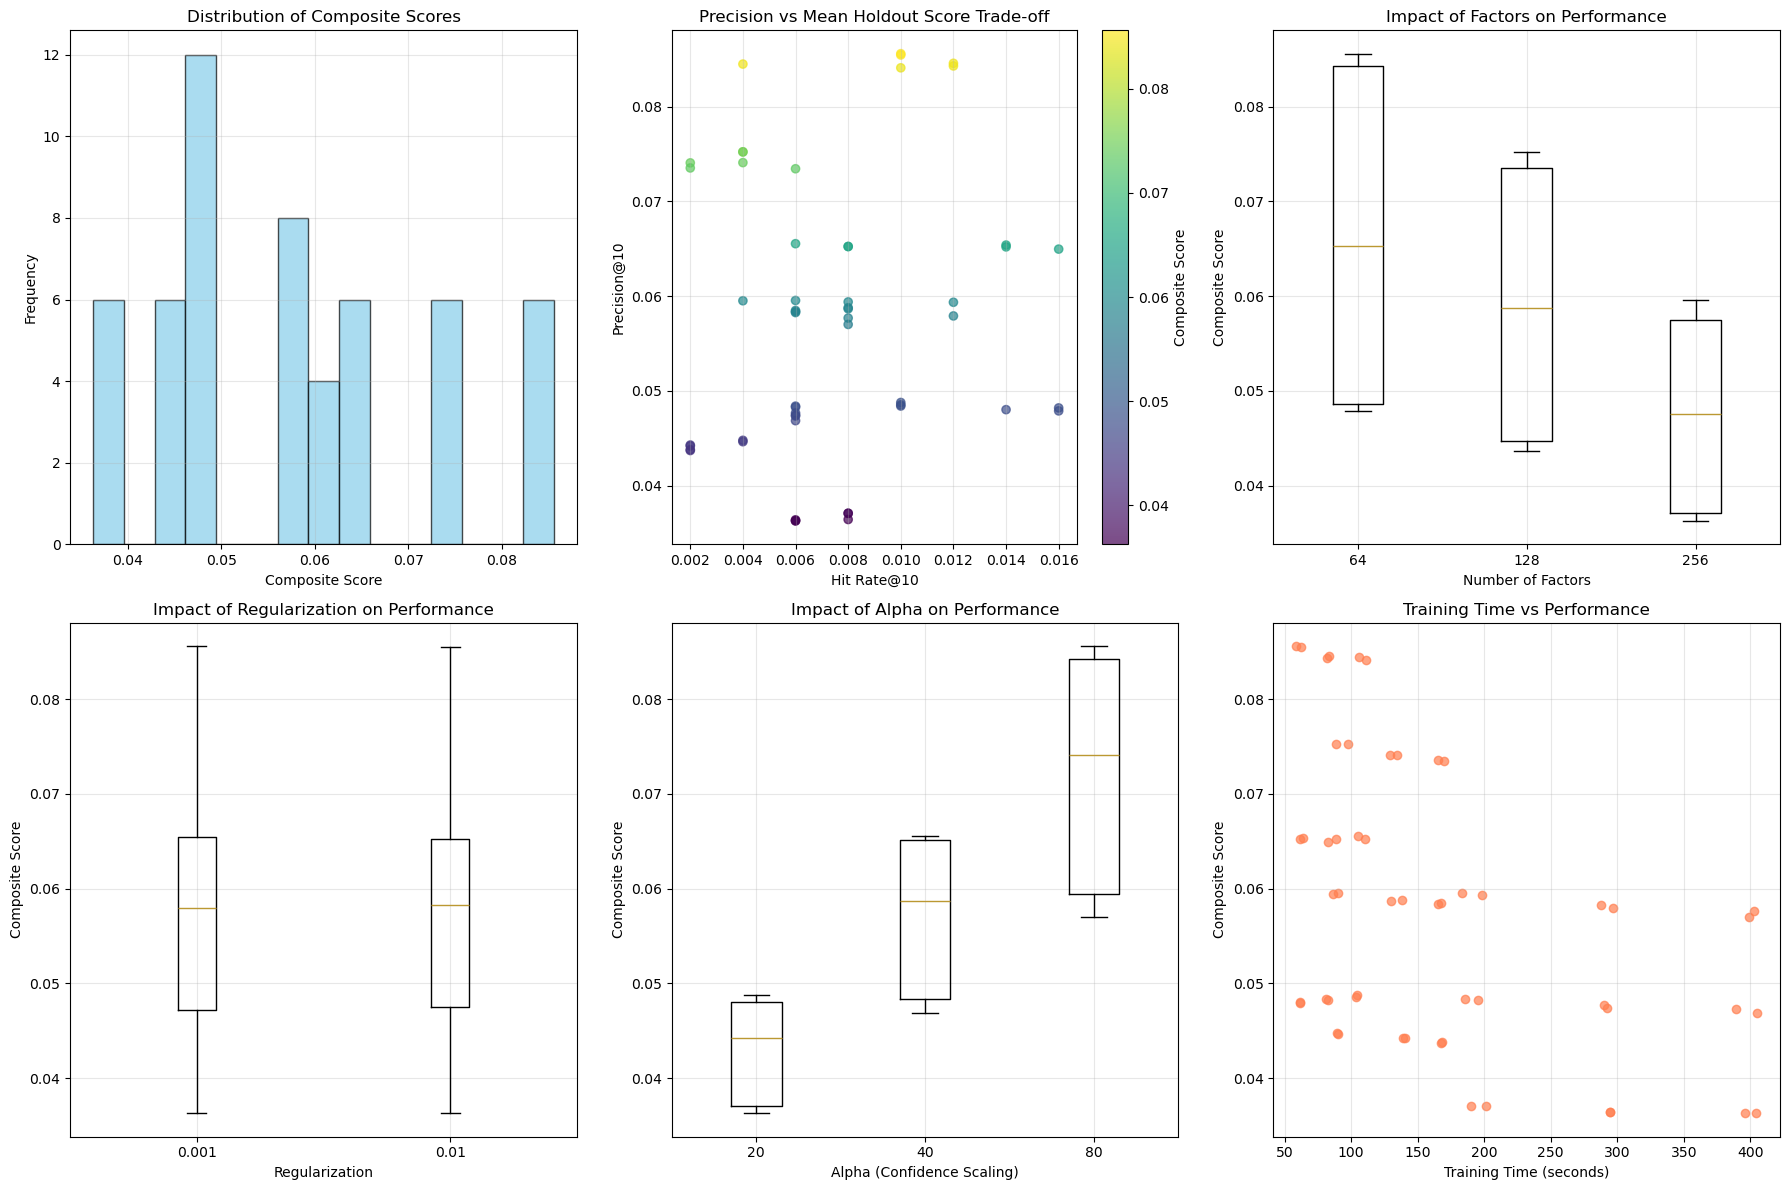


🏆 TOP 5 CONFIGURATIONS:

#1 - Composite Score: 0.0856
   Factors: 64.0, Regularization: 0.001, Iterations: 15.0, Alpha: 80.0
   Hit Rate@10: 0.0100, Precision@10: 0.0010
   Training time: 58.8s

#2 - Composite Score: 0.0855
   Factors: 64.0, Regularization: 0.01, Iterations: 15.0, Alpha: 80.0
   Hit Rate@10: 0.0100, Precision@10: 0.0010
   Training time: 61.9s

#3 - Composite Score: 0.0846
   Factors: 64.0, Regularization: 0.001, Iterations: 25.0, Alpha: 80.0
   Hit Rate@10: 0.0120, Precision@10: 0.0012
   Training time: 83.1s

#4 - Composite Score: 0.0845
   Factors: 64.0, Regularization: 0.001, Iterations: 35.0, Alpha: 80.0
   Hit Rate@10: 0.0040, Precision@10: 0.0004
   Training time: 105.6s

#5 - Composite Score: 0.0843
   Factors: 64.0, Regularization: 0.01, Iterations: 25.0, Alpha: 80.0
   Hit Rate@10: 0.0120, Precision@10: 0.0012
   Training time: 82.0s


In [ ]:


# Visualize hyperparameter tuning results
def visualize_tuning_results(results):
    
    #Create comprehensive visualizations of hyperparameter tuning results
    
    print("📊 HYPERPARAMETER TUNING RESULTS ANALYSIS")
    print("="*50)
    
    if not results:
        print("❌ No tuning results to visualize!")
        return
    
    # Convert to DataFrame for easier analysis
    import pandas as pd
    
    # Flatten the results for DataFrame creation
    flattened_results = []
    for result in results:
        row = result.copy()
        # Flatten parameters
        if 'params' in row:
            for param, value in row['params'].items():
                row[param] = value
            del row['params']
        flattened_results.append(row)
    
    df_results = pd.DataFrame(flattened_results)
    
    # Remove failed configurations
    df_results_clean = df_results[df_results['composite_score'] > 0].copy()
    
    print(f"📈 Analysis of {len(df_results_clean)} successful configurations:")
    print(f"   Best composite score: {df_results_clean['composite_score'].max():.4f}")
    print(f"   Worst composite score: {df_results_clean['composite_score'].min():.4f}")
    print(f"   Mean composite score: {df_results_clean['composite_score'].mean():.4f}")
    
    # Create visualizations
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Composite score distribution
    axes[0, 0].hist(df_results_clean['composite_score'], bins=15, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].set_title('Distribution of Composite Scores')
    axes[0, 0].set_xlabel('Composite Score')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Hit Rate@10 vs Precision@10
    scatter = axes[0, 1].scatter(df_results_clean['hit_rate_10'], df_results_clean['mean_holdout_score'], 
                               c=df_results_clean['composite_score'], cmap='viridis', alpha=0.7)
    axes[0, 1].set_xlabel('Hit Rate@10')
    axes[0, 1].set_ylabel('Precision@10')
    axes[0, 1].set_title('Precision vs Mean Holdout Score Trade-off')
    axes[0, 1].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0, 1], label='Composite Score')
    
    # 3. Parameter impact: Factors vs Composite Score
    if 'factors' in df_results_clean.columns:
        axes[0, 2].boxplot([df_results_clean[df_results_clean['factors'] == f]['composite_score'].values 
                           for f in sorted(df_results_clean['factors'].unique())], 
                          labels=sorted(df_results_clean['factors'].unique()))
        axes[0, 2].set_title('Impact of Factors on Performance')
        axes[0, 2].set_xlabel('Number of Factors')
        axes[0, 2].set_ylabel('Composite Score')
        axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Parameter impact: Regularization vs Composite Score  
    if 'regularization' in df_results_clean.columns:
        axes[1, 0].boxplot([df_results_clean[df_results_clean['regularization'] == r]['composite_score'].values 
                           for r in sorted(df_results_clean['regularization'].unique())],
                          labels=sorted(df_results_clean['regularization'].unique()))
        axes[1, 0].set_title('Impact of Regularization on Performance')
        axes[1, 0].set_xlabel('Regularization')
        axes[1, 0].set_ylabel('Composite Score')
        axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Parameter impact: Alpha vs Composite Score
    if 'alpha' in df_results_clean.columns:
        axes[1, 1].boxplot([df_results_clean[df_results_clean['alpha'] == a]['composite_score'].values 
                           for a in sorted(df_results_clean['alpha'].unique())],
                          labels=sorted(df_results_clean['alpha'].unique()))
        axes[1, 1].set_title('Impact of Alpha on Performance')
        axes[1, 1].set_xlabel('Alpha (Confidence Scaling)')
        axes[1, 1].set_ylabel('Composite Score')
        axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Training time vs Performance
    axes[1, 2].scatter(df_results_clean['training_time'], df_results_clean['composite_score'],
                      alpha=0.7, color='coral')
    axes[1, 2].set_xlabel('Training Time (seconds)')
    axes[1, 2].set_ylabel('Composite Score')
    axes[1, 2].set_title('Training Time vs Performance')
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Top 5 configurations
    print(f"\n🏆 TOP 5 CONFIGURATIONS:")
    print(f"=" * 40)
    top_5 = df_results_clean.nlargest(5, 'composite_score')
    
    for i, (_, row) in enumerate(top_5.iterrows(), 1):
        print(f"\n#{i} - Composite Score: {row['composite_score']:.4f}")
        print(f"   Factors: {row.get('factors', 'N/A')}, "
              f"Regularization: {row.get('regularization', 'N/A')}, "
              f"Iterations: {row.get('iterations', 'N/A')}, "
              f"Alpha: {row.get('alpha', 'N/A')}")
        print(f"   Hit Rate@10: {row['hit_rate_10']:.4f}, "
              f"Precision@10: {row['precision_10']:.4f}")
        print(f"   Training time: {row['training_time']:.1f}s")
    
    return df_results_clean

# 🚀 VISUALIZE TUNING RESULTS (run after hyperparameter tuning completes)
if 'tuning_results' in locals():
    print("📊 Analyzing and visualizing hyperparameter tuning results...")
    results_df = visualize_tuning_results(tuning_results)
else:
    print("⚠️  Run the hyperparameter tuning cell first to generate results!")




In [ ]:

# Train optimized model with best hyperparameters
def train_optimized_model(df_train, best_params):
    
    #Train the final optimized model using the best hyperparameters found
    #This function only trains the model - no evaluation included
    
    print("🎯 TRAINING OPTIMIZED MODEL WITH BEST HYPERPARAMETERS")
    print("="*55)
    
    print(f"🔧 Best hyperparameters:")
    for param, value in best_params.items():
        print(f"   {param}: {value}")
    
    # Create matrices for the optimized model
    print(f"\n📊 Creating user-item matrix...")
    optimized_matrix, optimized_user_to_idx, optimized_item_to_idx, optimized_idx_to_user, optimized_idx_to_item = create_user_item_matrix(df_train)
    
    # Train optimized model
    print(f"\n🚀 Training optimized ALS model...")
    optimized_model, optimized_item_user_matrix = train_als_model(
        optimized_matrix,
        factors=best_params['factors'],
        regularization=best_params['regularization'], 
        iterations=best_params['iterations'],
        alpha=best_params['alpha']
    )
    
    print(f"\n✅ Optimized model training complete!")
    
    
    print(f"\n📊 Model summary:")
    print(f"   Users: {len(optimized_user_to_idx):,}")
    print(f"   Items: {len(optimized_idx_to_item):,}")
    print(f"   Matrix sparsity: {(1 - optimized_matrix.nnz / (optimized_matrix.shape[0] * optimized_matrix.shape[1]))*100:.2f}%")
    
    return optimized_model, optimized_matrix, optimized_user_to_idx, optimized_idx_to_item

# 🚀 TRAIN OPTIMIZED MODEL (TRAINING ONLY)
if 'best_hyperparams' in locals() and best_hyperparams is not None:
    print("🚀 TRAINING OPTIMIZED MODEL...")
    print()
    
    # Train the optimized model (no evaluation)
    optimized_model, optimized_matrix, optimized_user_to_idx, optimized_idx_to_item = train_optimized_model(
        df_train, best_hyperparams
    )
    
    print(f"\n🎉 OPTIMIZED MODEL READY!")
    print(f"💡 Use evaluation cells later to test model performance")
    
else:
    print("⚠️  Run the hyperparameter tuning cell first to find best parameters!")



🚀 TRAINING OPTIMIZED MODEL...

🎯 TRAINING OPTIMIZED MODEL WITH BEST HYPERPARAMETERS
🔧 Best hyperparameters:
   factors: 64
   regularization: 0.001
   iterations: 15
   alpha: 80

📊 Creating user-item matrix...
Creating user-item interaction matrix...
Matrix dimensions: 15311 users × 1771634 items
Matrix dimensions: 15311 users × 1771634 items
Sparsity: 99.97%
Total interactions: 9,118,393

🚀 Training optimized ALS model...
Training ALS model...
Parameters: factors=64, regularization=0.001, iterations=15, alpha=80
Sparsity: 99.97%
Total interactions: 9,118,393

🚀 Training optimized ALS model...
Training ALS model...
Parameters: factors=64, regularization=0.001, iterations=15, alpha=80


  0%|          | 0/15 [00:00<?, ?it/s]

✅ ALS model trained successfully!

✅ Optimized model training complete!

📊 Model summary:
   Users: 15,311
   Items: 1,771,634
   Matrix sparsity: 99.97%

🎉 OPTIMIZED MODEL READY!
💡 Use evaluation cells later to test model performance


## 11. Additional Model Optimization Strategies

Beyond hyperparameter tuning, here are additional strategies to improve recommender system performance:

### 🔧 **Advanced Optimization Techniques:**

1. **Data Preprocessing:**
   - **User/Item filtering**: Remove users/items with very few interactions
   - **Interaction weighting**: Weight interactions by frequency, recency, or explicit ratings
   - **Cold start handling**: Special treatment for new users/items

2. **Feature Engineering:**
   - **Implicit feedback scaling**: Different confidence scaling for different interaction types
   - **Temporal factors**: Account for when interactions occurred
   - **Content features**: Incorporate track metadata (genre, artist, etc.)

3. **Ensemble Methods:**
   - **Model stacking**: Combine multiple ALS models with different parameters
   - **Hybrid approaches**: Blend collaborative filtering with content-based methods
   - **Cross-validation**: Use multiple train/validation splits

4. **Alternative Algorithms:**
   - **Neural Collaborative Filtering**: Deep learning approaches
   - **Matrix factorization variants**: SVD++, Non-negative Matrix Factorization
   - **Graph-based methods**: Node2Vec, GraphSAGE for user-item graphs

### 📊 **Performance Benchmarks:**
- **Good Hit Rate@10**: 15-30% for music recommendation
- **Good Precision@10**: 5-15% depending on catalog size
- **Score distribution**: Higher scores for actual interactions vs. random

## 12. Model Persistence - Save & Load Optimized Models

To avoid repeating the time-consuming hyperparameter tuning process, we'll save the optimized model and its parameters to files. This allows you to quickly load the best model in future notebook sessions.

In [ ]:



# Model saving and loading functions
import pickle
import json
import os
from datetime import datetime

def save_optimized_model(model, best_params, tuning_results, user_to_idx, idx_to_item, 
                        model_dir='./saved_models/', model_name=None):
    
    #Save the optimized ALS model and all associated data to files
    
    #Parameters:
    #- model: trained implicit ALS model
    #- best_params: dictionary of best hyperparameters
    #- tuning_results: results from hyperparameter tuning
    #- user_to_idx: user ID to index mapping
    #- idx_to_item: index to item (track) mapping
    #- model_dir: directory to save model files
    #- model_name: custom name for model files (auto-generated if None)
    
    print("💾 SAVING OPTIMIZED MODEL AND METADATA")
    print("="*45)
    
    # Create model directory if it doesn't exist
    os.makedirs(model_dir, exist_ok=True)
    
    # Generate model name with timestamp if not provided
    if model_name is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        model_name = f"als_optimized_{timestamp}"
    
    print(f"📁 Saving model as: {model_name}")
    print(f"📁 Save directory: {model_dir}")
    
    # File paths
    model_file = os.path.join(model_dir, f"{model_name}_model.pkl")
    params_file = os.path.join(model_dir, f"{model_name}_params.json")
    mappings_file = os.path.join(model_dir, f"{model_name}_mappings.pkl")
    results_file = os.path.join(model_dir, f"{model_name}_tuning_results.pkl")
    metadata_file = os.path.join(model_dir, f"{model_name}_metadata.json")
    
    try:
        # 1. Save the trained model
        print("💾 Saving trained ALS model...")
        with open(model_file, 'wb') as f:
            pickle.dump(model, f)
        print(f"   ✅ Model saved: {model_file}")
        
        # 2. Save hyperparameters
        print("💾 Saving best hyperparameters...")
        with open(params_file, 'w') as f:
            json.dump(best_params, f, indent=2)
        print(f"   ✅ Parameters saved: {params_file}")
        
        # 3. Save user/item mappings
        print("💾 Saving user/item mappings...")
        mappings = {
            'user_to_idx': user_to_idx,
            'idx_to_item': idx_to_item
        }
        with open(mappings_file, 'wb') as f:
            pickle.dump(mappings, f)
        print(f"   ✅ Mappings saved: {mappings_file}")
        
        # 4. Save tuning results
        print("💾 Saving hyperparameter tuning results...")
        with open(results_file, 'wb') as f:
            pickle.dump(tuning_results, f)
        print(f"   ✅ Tuning results saved: {results_file}")
        
        # 5. Save metadata
        print("💾 Saving model metadata...")
        
        # Helper function to convert NumPy types to native Python types for JSON serialization
        def convert_numpy_types(obj):
            import numpy as np
            if isinstance(obj, np.integer):
                return int(obj)
            elif isinstance(obj, np.floating):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            return obj
        
        # Calculate model statistics with type conversion
        successful_results = [r for r in tuning_results if r.get('composite_score', -999) > -999]
        best_score = max([convert_numpy_types(r.get('composite_score', -999)) for r in tuning_results]) if tuning_results else 0
        
        metadata = {
            'model_name': model_name,
            'save_timestamp': datetime.now().isoformat(),
            'best_hyperparameters': best_params,
            'model_statistics': {
                'n_users': len(user_to_idx),
                'n_items': len(idx_to_item),
                'factors': convert_numpy_types(best_params.get('factors', 'unknown')),
                'regularization': convert_numpy_types(best_params.get('regularization', 'unknown')),
                'iterations': convert_numpy_types(best_params.get('iterations', 'unknown')),
                'alpha': convert_numpy_types(best_params.get('alpha', 'unknown'))
            },
            'tuning_summary': {
                'total_configurations_tested': len(tuning_results),
                'successful_configurations': len(successful_results),
                'best_score': convert_numpy_types(best_score),
                'optimization_metric': 'mean_holdout_score'
            },
            'file_paths': {
                'model': model_file,
                'parameters': params_file,
                'mappings': mappings_file,
                'tuning_results': results_file,
                'metadata': metadata_file
            }
        }
        
        with open(metadata_file, 'w') as f:
            json.dump(metadata, f, indent=2)
        print(f"   ✅ Metadata saved: {metadata_file}")
        
        # Calculate total file sizes
        total_size = 0
        for filepath in [model_file, params_file, mappings_file, results_file, metadata_file]:
            if os.path.exists(filepath):
                total_size += os.path.getsize(filepath)
        
        print(f"\n🎉 MODEL SAVE COMPLETE!")
        print(f"📊 Summary:")
        print(f"   Model name: {model_name}")
        print(f"   Files saved: 5")
        print(f"   Total size: {total_size / (1024*1024):.1f} MB")
        print(f"   Best parameters: {best_params}")
        
        return model_name, metadata
        
    except Exception as e:
        print(f"❌ Error saving model: {str(e)}")
        return None, None

def load_optimized_model(model_name, model_dir='./saved_models/'):
    
    #Load a previously saved optimized model and all associated data
    
    #Parameters:
    #- model_name: name of the saved model (without file extensions)
    #- model_dir: directory where model files are stored
    
    #Returns:
    #- model: loaded ALS model
    #- best_params: best hyperparameters
    #- user_to_idx: user ID to index mapping
    #- idx_to_item: index to item mapping
    #- metadata: model metadata
    
    print(f"📖 LOADING OPTIMIZED MODEL: {model_name}")
    print("="*45)
    
    # File paths
    model_file = os.path.join(model_dir, f"{model_name}_model.pkl")
    params_file = os.path.join(model_dir, f"{model_name}_params.json")
    mappings_file = os.path.join(model_dir, f"{model_name}_mappings.pkl")
    metadata_file = os.path.join(model_dir, f"{model_name}_metadata.json")
    
    try:
        # Check if all required files exist
        required_files = [model_file, params_file, mappings_file, metadata_file]
        missing_files = [f for f in required_files if not os.path.exists(f)]
        
        if missing_files:
            print(f"❌ Missing files: {missing_files}")
            return None, None, None, None, None
        
        # 1. Load metadata first
        print("📖 Loading metadata...")
        with open(metadata_file, 'r') as f:
            metadata = json.load(f)
        print(f"   ✅ Model saved: {metadata['save_timestamp']}")
        print(f"   ✅ Best score: {metadata['tuning_summary']['best_composite_score']:.4f}")
        
        # 2. Load hyperparameters
        print("📖 Loading hyperparameters...")
        with open(params_file, 'r') as f:
            best_params = json.load(f)
        print(f"   ✅ Parameters: {best_params}")
        
        # 3. Load mappings
        print("📖 Loading user/item mappings...")
        with open(mappings_file, 'rb') as f:
            mappings = pickle.load(f)
        user_to_idx = mappings['user_to_idx']
        idx_to_item = mappings['idx_to_item']
        print(f"   ✅ Users: {len(user_to_idx):,}, Items: {len(idx_to_item):,}")
        
        # 4. Load trained model
        print("📖 Loading trained ALS model...")
        with open(model_file, 'rb') as f:
            model = pickle.load(f)
        print(f"   ✅ Model loaded successfully!")
        
        print(f"\n🎉 MODEL LOAD COMPLETE!")
        print(f"📊 Model ready for recommendations and evaluation")
        
        return model, best_params, user_to_idx, idx_to_item, metadata
        
    except Exception as e:
        print(f"❌ Error loading model: {str(e)}")
        return None, None, None, None, None

        
def list_saved_models(model_dir='./saved_models/'):
    
    #List all saved models in the model directory
    
    print(f"📁 SAVED MODELS IN: {model_dir}")
    print("="*40)
    
    if not os.path.exists(model_dir):
        print(f"❌ Directory does not exist: {model_dir}")
        return []
    
    # Find all metadata files
    metadata_files = [f for f in os.listdir(model_dir) if f.endswith('_metadata.json')]
    
    if not metadata_files:
        print(f"📭 No saved models found")
        return []
    
    models = []
    for metadata_file in metadata_files:
        try:
            with open(os.path.join(model_dir, metadata_file), 'r') as f:
                metadata = json.load(f)
            
            model_name = metadata['model_name']
            save_time = metadata['save_timestamp']
            
            # Handle both old and new metadata formats
            tuning_summary = metadata.get('tuning_summary', {})
            best_score = tuning_summary.get('best_score')  # New format
            if best_score is None:
                best_score = tuning_summary.get('best_composite_score', 0.0)  # Old format fallback
            
            best_params = metadata['best_hyperparameters']
            
            models.append({
                'name': model_name,
                'save_time': save_time,
                'best_score': best_score,
                'params': best_params
            })
            
        except json.JSONDecodeError as e:
            print(f"⚠️  Corrupted JSON in {metadata_file}: {str(e)[:50]}... (skipping)")
        except KeyError as e:
            print(f"⚠️  Missing key in {metadata_file}: {str(e)[:50]}... (skipping)")
        except Exception as e:
            print(f"⚠️  Error reading {metadata_file}: {str(e)[:50]}... (skipping)")
    
    # Sort by save time (newest first)
    models.sort(key=lambda x: x['save_time'], reverse=True)
    
    print(f"Found {len(models)} saved model(s):")
    print()
    
    for i, model in enumerate(models, 1):
        save_date = datetime.fromisoformat(model['save_time']).strftime("%Y-%m-%d %H:%M")
        print(f"{i}. {model['name']}")
        print(f"   Saved: {save_date}")
        print(f"   Best score: {model['best_score']:.4f}")
        print(f"   Parameters: factors={model['params'].get('factors')}, "
              f"reg={model['params'].get('regularization')}, "
              f"iter={model['params'].get('iterations')}, "
              f"alpha={model['params'].get('alpha')}")
        print()
    
    return models

def clean_corrupted_models(model_dir='./saved_models/'):
    
    #Remove corrupted model files that can't be loaded properly
    
    print(f"🧹 CLEANING CORRUPTED MODEL FILES")
    print("="*40)
    
    if not os.path.exists(model_dir):
        print(f"❌ Directory does not exist: {model_dir}")
        return
    
    # Find all metadata files
    metadata_files = [f for f in os.listdir(model_dir) if f.endswith('_metadata.json')]
    
    corrupted_models = []
    
    for metadata_file in metadata_files:
        try:
            with open(os.path.join(model_dir, metadata_file), 'r') as f:
                metadata = json.load(f)
            # If we can load it, it's fine
            
        except Exception as e:
            print(f"⚠️  Found corrupted metadata: {metadata_file}")
            model_base_name = metadata_file.replace('_metadata.json', '')
            corrupted_models.append(model_base_name)
    
    if not corrupted_models:
        print("✅ No corrupted model files found")
        return
    
    print(f"\nFound {len(corrupted_models)} corrupted model(s):")
    for model_name in corrupted_models:
        print(f"  - {model_name}")
    
    response = input("\n🗑️  Delete corrupted model files? (y/N): ").strip().lower()
    
    if response in ['y', 'yes']:
        for model_name in corrupted_models:
            # Delete all files associated with this model
            extensions = ['_model.pkl', '_params.json', '_mappings.pkl', 
                         '_tuning_results.pkl', '_metadata.json']
            
            deleted_count = 0
            for ext in extensions:
                file_path = os.path.join(model_dir, f"{model_name}{ext}")
                if os.path.exists(file_path):
                    os.remove(file_path)
                    deleted_count += 1
            
            print(f"🗑️  Deleted {deleted_count} files for {model_name}")
        
        print(f"\n✅ Cleaned up {len(corrupted_models)} corrupted model(s)")
    else:
        print("❌ Cleanup cancelled")

# 🔍 LIST EXISTING SAVED MODELS
print("🔍 Checking for existing saved models...")
existing_models = list_saved_models()

# If there are issues, offer to clean them up
if len(existing_models) == 0:
    print("\n🧹 If you're having issues with corrupted model files, run:")
    print("   clean_corrupted_models()")



🔍 Checking for existing saved models...
📁 SAVED MODELS IN: ./saved_models/
⚠️  Corrupted JSON in als_optimized_f64_r0.001_i15_a80_metadata.json: Expecting value: line 21 column 29 (char 510)... (skipping)
Found 1 saved model(s):

1. als_optimized_f64_r0.01_i25_a20
   Saved: 2025-12-07 16:06
   Best score: 0.0079
   Parameters: factors=64, reg=0.01, iter=25, alpha=20



In [ ]:



# Save the optimized model (run this after hyperparameter tuning completes)
def save_current_optimized_model():
    
    #Save the currently optimized model if it exists
    
    # Check if we have the required variables from hyperparameter tuning
    required_vars = ['optimized_model', 'best_hyperparams', 'tuning_results', 
                    'optimized_user_to_idx', 'optimized_idx_to_item']
    
    missing_vars = [var for var in required_vars if var not in locals() and var not in globals()]
    
    if missing_vars:
        print("❌ Cannot save model - missing variables:")
        for var in missing_vars:
            print(f"   - {var}")
        print("\n💡 Make sure you've run the hyperparameter tuning and model training cells!")
        return None
    
    # Get the variables from global scope
    model = globals().get('optimized_model')
    params = globals().get('best_hyperparams') 
    results = globals().get('tuning_results')
    user_idx = globals().get('optimized_user_to_idx')
    idx_item = globals().get('optimized_idx_to_item')
    
    if any(var is None for var in [model, params, results, user_idx, idx_item]):
        print("❌ Some required variables are None. Run hyperparameter tuning first!")
        return None
    
    # Generate a descriptive model name
    factors = params.get('factors', 'unk')
    reg = params.get('regularization', 'unk')
    iterations = params.get('iterations', 'unk')
    alpha = params.get('alpha', 'unk')
    
    model_name = f"als_optimized_f{factors}_r{reg}_i{iterations}_a{alpha}"
    
    print(f"💾 Saving optimized model with hyperparameters:")
    print(f"   factors={factors}, regularization={reg}, iterations={iterations}, alpha={alpha}")
    
    # Save the model
    saved_name, metadata = save_optimized_model(
        model=model,
        best_params=params,
        tuning_results=results,
        user_to_idx=user_idx,
        idx_to_item=idx_item,
        model_name=model_name
    )
    
    if saved_name:
        print(f"\n🎉 SUCCESS! Model saved as: {saved_name}")
        print(f"💡 You can now load this model in future sessions to skip hyperparameter tuning!")
    
    return saved_name

# 📖 SAVE OPTIMIZED MODEL (if available)
if 'optimized_model' in locals() or 'optimized_model' in globals():
    print("💾 SAVING OPTIMIZED MODEL...")
    save_current_optimized_model()
else:
    print("⚠️  No optimized model found to save.")
    print("💡 Run the hyperparameter tuning cells first to create an optimized model!")



💾 SAVING OPTIMIZED MODEL...
💾 Saving optimized model with hyperparameters:
   factors=64, regularization=0.001, iterations=15, alpha=80
💾 SAVING OPTIMIZED MODEL AND METADATA
📁 Saving model as: als_optimized_f64_r0.001_i15_a80
📁 Save directory: ./saved_models/
💾 Saving trained ALS model...
   ✅ Model saved: ./saved_models/als_optimized_f64_r0.001_i15_a80_model.pkl
💾 Saving best hyperparameters...
   ✅ Parameters saved: ./saved_models/als_optimized_f64_r0.001_i15_a80_params.json
💾 Saving user/item mappings...
   ✅ Model saved: ./saved_models/als_optimized_f64_r0.001_i15_a80_model.pkl
💾 Saving best hyperparameters...
   ✅ Parameters saved: ./saved_models/als_optimized_f64_r0.001_i15_a80_params.json
💾 Saving user/item mappings...
   ✅ Mappings saved: ./saved_models/als_optimized_f64_r0.001_i15_a80_mappings.pkl
💾 Saving hyperparameter tuning results...
   ✅ Tuning results saved: ./saved_models/als_optimized_f64_r0.001_i15_a80_tuning_results.pkl
💾 Saving model metadata...
   ✅ Metadata saved

In [31]:
# Load a previously saved optimized model (QUICK START option)
def quick_load_best_model():
    """
    Quick function to load the best saved model automatically
    """
    print("🚀 QUICK LOAD: Finding and loading best saved model...")
    
    # List available models
    models = list_saved_models()
    
    if not models:
        print("❌ No saved models found!")
        print("💡 Run hyperparameter tuning first to create a model to save.")
        return None, None, None, None, None
    
    # Find the model with the best score
    best_model = max(models, key=lambda x: x['best_score'])
    
    print(f"\n🎯 Loading best model: {best_model['name']}")
    print(f"   Best score: {best_model['best_score']:.4f}")
    print(f"   Parameters: {best_model['params']}")
    
    # Load the model
    model, params, user_to_idx, idx_to_item, metadata = load_optimized_model(best_model['name'])
    
    if model is not None:
        print(f"\n✅ QUICK LOAD SUCCESSFUL!")
        print(f"🎉 Ready to use optimized model without hyperparameter tuning!")
        
        # Set global variables so other cells can use the loaded model
        globals()['loaded_optimized_model'] = model
        globals()['loaded_best_params'] = params
        globals()['loaded_user_to_idx'] = user_to_idx  
        globals()['loaded_idx_to_item'] = idx_to_item
        globals()['loaded_metadata'] = metadata
        
        print(f"\n📊 Loaded model statistics:")
        print(f"   Users: {len(user_to_idx):,}")
        print(f"   Items: {len(idx_to_item):,}")
        print(f"   Model factors: {params.get('factors')}")
        print(f"   Regularization: {params.get('regularization')}")
        print(f"   Iterations: {params.get('iterations')}")
        print(f"   Alpha: {params.get('alpha')}")
        
        return model, params, user_to_idx, idx_to_item, metadata
    else:
        print(f"❌ Failed to load model!")
        return None, None, None, None, None

# Load specific model by name
def load_specific_model(model_name):
    """
    Load a specific saved model by name
    """
    print(f"📖 Loading specific model: {model_name}")
    
    model, params, user_to_idx, idx_to_item, metadata = load_optimized_model(model_name)
    
    if model is not None:
        # Set global variables
        globals()['loaded_optimized_model'] = model
        globals()['loaded_best_params'] = params
        globals()['loaded_user_to_idx'] = user_to_idx
        globals()['loaded_idx_to_item'] = idx_to_item
        globals()['loaded_metadata'] = metadata
        
        print(f"✅ Model '{model_name}' loaded successfully!")
        return model, params, user_to_idx, idx_to_item, metadata
    else:
        print(f"❌ Failed to load model '{model_name}'")
        return None, None, None, None, None

# 🚀 QUICK START: Load best model automatically
print("🚀 QUICK START OPTION: Load Previously Optimized Model")
print("="*55)
print("💡 Choose one option:")
print("   A) Run the cell below to auto-load the best saved model")
print("   B) Run hyperparameter tuning if no saved models exist")
print("   C) Load a specific model by name using load_specific_model('model_name')")
print()

# Uncomment the line below to automatically load the best model
# quick_load_best_model()

🚀 QUICK START OPTION: Load Previously Optimized Model
💡 Choose one option:
   A) Run the cell below to auto-load the best saved model
   B) Run hyperparameter tuning if no saved models exist
   C) Load a specific model by name using load_specific_model('model_name')



In [33]:
# 🚀 LOAD YOUR SAVED OPTIMIZED MODEL
print("🚀 LOADING SAVED OPTIMIZED MODEL FOR EVALUATION")
print("="*50)

# First, let's see what models are available
models = list_saved_models()

if models:
    print("\n📋 Available saved models:")
    for i, model in enumerate(models, 1):
        save_date = datetime.fromisoformat(model['save_time']).strftime("%Y-%m-%d %H:%M")
        print(f"{i}. {model['name']}")
        print(f"   Saved: {save_date}")
        print(f"   Best score: {model['best_score']:.4f}")
        print()
    
    # Load the best model automatically
    print("🎯 Loading the best model automatically...")
    quick_load_best_model()
    
else:
    print("\n❌ No saved models found!")
    print("💡 Please run the hyperparameter tuning cells first to create a saved model.")
    print("   Then save it using the model saving cell before running this evaluation.")

🚀 LOADING SAVED OPTIMIZED MODEL FOR EVALUATION
📁 SAVED MODELS IN: ./saved_models/
Found 1 saved model(s):

1. als_optimized_f64_r0.01_i25_a20
   Saved: 2025-12-07 16:06
   Best score: 0.0079
   Parameters: factors=64, reg=0.01, iter=25, alpha=20


📋 Available saved models:
1. als_optimized_f64_r0.01_i25_a20
   Saved: 2025-12-07 16:06
   Best score: 0.0079

🎯 Loading the best model automatically...
🚀 QUICK LOAD: Finding and loading best saved model...
📁 SAVED MODELS IN: ./saved_models/
Found 1 saved model(s):

1. als_optimized_f64_r0.01_i25_a20
   Saved: 2025-12-07 16:06
   Best score: 0.0079
   Parameters: factors=64, reg=0.01, iter=25, alpha=20


🎯 Loading best model: als_optimized_f64_r0.01_i25_a20
   Best score: 0.0079
   Parameters: {'factors': 64, 'regularization': 0.01, 'iterations': 25, 'alpha': 20}
📖 LOADING OPTIMIZED MODEL: als_optimized_f64_r0.01_i25_a20
📖 Loading metadata...
   ✅ Model saved: 2025-12-07T16:06:06.266697
   ✅ Best score: 0.0079
📖 Loading hyperparameters...
   

In [63]:
# Comprehensive Evaluation of Optimized Model
print("🧪 COMPREHENSIVE EVALUATION OF OPTIMIZED MODEL")
print("="*55)

# Check if we have the optimized model available
if 'optimized_model' in locals() and 'optimized_user_to_idx' in locals() and 'optimized_idx_to_item' in locals():
    print("✅ Optimized model found - proceeding with evaluation")
    
    # Use the optimized model and mappings
    eval_model = optimized_model
    eval_user_to_idx = optimized_user_to_idx
    eval_idx_to_item = optimized_idx_to_item
    model_name = "OPTIMIZED MODEL"
    
elif 'loaded_optimized_model' in locals() and 'loaded_user_to_idx' in locals() and 'loaded_idx_to_item' in locals():
    print("✅ Loaded optimized model found - proceeding with evaluation")
    
    # Use the loaded model and mappings
    eval_model = loaded_optimized_model
    eval_user_to_idx = loaded_user_to_idx
    eval_idx_to_item = loaded_idx_to_item
    model_name = "LOADED OPTIMIZED MODEL"
    
else:
    print("❌ No optimized model found!")
    print("💡 Please run one of the following:")
    print("   1. Hyperparameter tuning + optimized model training cells")
    print("   2. Load saved optimized model cell")
    eval_model = None

# Proceed with evaluation if we have a model
if eval_model is not None:
    print(f"\n📊 Evaluating: {model_name}")
    print(f"   Model users: {len(eval_user_to_idx):,}")
    print(f"   Model items: {len(eval_idx_to_item):,}")
    
    # =================================================================
    # 1. VALIDATION METRICS (Precision, Recall, Hit Rate)
    # =================================================================
    print(f"\n🎯 PART 1: VALIDATION METRICS")
    print("="*40)
    
    # Use the fixed validation function for reliable results (avoids index bounds errors)
    optimized_validation_results = fast_validation_metrics(
        df_validation, 
        eval_model, 
        eval_user_to_idx, 
        eval_idx_to_item,
        k_values=[5, 10, 20], 
        max_users=1000  # Evaluate on 1000 users for good statistics
    )
    
    # =================================================================
    # 2. SCORE DISTRIBUTION ANALYSIS
    # =================================================================
    print(f"\n📊 PART 2: SCORE DISTRIBUTION FOR HELD-OUT INTERACTIONS")
    print("="*55)
    
    # Simple score analysis using manual recommendations (avoiding index bounds errors)
    print("Analyzing score distribution for held-out interactions...")
    
    def analyze_holdout_scores_simple(df_validation, model, user_to_idx, idx_to_item, max_users=500):
        """Simple score analysis that avoids index bounds errors"""
        # Create reverse mapping
        item_to_idx = {item: idx for idx, item in idx_to_item.items()}
        
        # Get users with validation data
        val_users = df_validation['user_id'].unique()
        
        # Filter to users in training data and sample
        valid_users = [u for u in val_users if u in user_to_idx]
        if len(valid_users) > max_users:
            np.random.seed(42)
            valid_users = np.random.choice(valid_users, max_users, replace=False)
        
        holdout_scores = []
        successful_users = 0
        
        for user_id in valid_users:
            try:
                # Get user's validation tracks
                user_tracks = df_validation[df_validation['user_id'] == user_id]['trackname'].unique()
                
                # Filter to tracks in training vocabulary
                valid_tracks = [t for t in user_tracks if t in item_to_idx]
                
                if len(valid_tracks) < 2:  # Need at least 2 tracks
                    continue
                
                # Get user index and calculate scores using manual method
                user_idx = user_to_idx[user_id]
                user_latent = model.user_factors[user_idx]
                
                # Calculate scores for user's validation tracks
                for track in valid_tracks:
                    item_idx = item_to_idx[track]
                    if item_idx < len(model.item_factors):  # Safety check
                        score = model.item_factors[item_idx].dot(user_latent)
                        holdout_scores.append(score)
                
                successful_users += 1
                
            except Exception as e:
                continue
        
        print(f"   Successfully analyzed {successful_users} users")
        print(f"   Total scores calculated: {len(holdout_scores)}")
        
        return np.array(holdout_scores)
    
    optimized_holdout_scores = analyze_holdout_scores_simple(
        df_validation, eval_model, eval_user_to_idx, eval_idx_to_item, max_users=1000
    )
    
    # =================================================================
    # 3. PERFORMANCE SUMMARY
    # =================================================================
    print(f"\n🏆 OPTIMIZED MODEL PERFORMANCE SUMMARY")
    print("="*45)
    
    print(f"\n📈 Validation Metrics:")
    for k in [5, 10, 20]:
        if k in optimized_validation_results:
            metrics = optimized_validation_results[k]
            hr = metrics['hit_rate']
            pr = metrics['precision'] 
            rc = metrics['recall']
            n_users = metrics['n_users']
            
            print(f"   📊 Top-{k} Recommendations:")
            print(f"      Hit Rate@{k}:   {hr:.4f} ({hr*100:.2f}%) - {hr*100:.1f}% of users got ≥1 relevant item")
            print(f"      Precision@{k}:  {pr:.4f} ({pr*100:.2f}%) - {pr*100:.1f}% of recommendations were relevant")
            print(f"      Recall@{k}:     {rc:.4f} ({rc*100:.2f}%) - Found {rc*100:.1f}% of user's relevant items")
            print(f"      Users evaluated: {n_users:,}")
            print()
    
    if len(optimized_holdout_scores) > 0:
        print(f"📊 Score Distribution for Held-out Interactions:")
        print(f"   Total interactions scored: {len(optimized_holdout_scores):,}")
        print(f"   Mean score:    {np.mean(optimized_holdout_scores):.4f}")
        print(f"   Median score:  {np.median(optimized_holdout_scores):.4f}")
        print(f"   Std deviation: {np.std(optimized_holdout_scores):.4f}")
        print(f"   Min score:     {np.min(optimized_holdout_scores):.4f}")
        print(f"   Max score:     {np.max(optimized_holdout_scores):.4f}")
        
        # Score percentiles
        percentiles = [10, 25, 50, 75, 90, 95]
        print(f"\n   Score Percentiles:")
        for p in percentiles:
            value = np.percentile(optimized_holdout_scores, p)
            print(f"      {p:2d}th percentile: {value:.4f}")
    
    # =================================================================
    # 4. COMPARISON WITH BASELINE (if available)
    # =================================================================
    if 'train_model' in locals() and 'train_user_to_idx' in locals() and 'train_idx_to_item' in locals():
        print(f"\n🔄 COMPARISON WITH BASELINE MODEL")
        print("="*35)
        
        # Quick baseline evaluation for comparison (with error handling)
        print("Evaluating baseline model for comparison...")
        print(f"   Baseline model type: {type(train_model)}")
        print(f"   Baseline users: {len(train_user_to_idx):,}")
        print(f"   Baseline items: {len(train_idx_to_item):,}")
        
        try:
            # Evaluate baseline model using the same k-values as the optimized model for fair comparison
            baseline_validation_results = fast_validation_metrics(
                df_validation, train_model, train_user_to_idx, train_idx_to_item,
                k_values=[5, 10, 20], max_users=500  # Same k_values as optimized model
            )
            
            baseline_holdout_scores = analyze_holdout_scores_simple(
                df_validation, train_model, train_user_to_idx, train_idx_to_item, max_users=800
            )
            
            # Comparison table
            print(f"\n📊 BASELINE vs OPTIMIZED COMPARISON:")
            print(f"{'Metric':<25} {'Baseline':<12} {'Optimized':<12} {'Improvement':<12}")
            print(f"{'-'*25} {'-'*12} {'-'*12} {'-'*12}")
            
            # Initialize improvement variables
            hr_improvement = 0
            pr_improvement = 0
            score_improvement = 0
            
            # Compare metrics for k=5, 10, 20 (all available in both results)
            comparison_metrics = []
            for k in [5, 10, 20]:
                if (baseline_validation_results and k in baseline_validation_results and 
                    optimized_validation_results and k in optimized_validation_results):
                    
                    baseline_metrics = baseline_validation_results[k]
                    optimized_metrics = optimized_validation_results[k]
                    
                    # Check if required keys exist
                    if ('hit_rate' in baseline_metrics and 'hit_rate' in optimized_metrics and
                        'precision' in baseline_metrics and 'precision' in optimized_metrics):
                        
                        baseline_hr = baseline_metrics['hit_rate']
                        optimized_hr = optimized_metrics['hit_rate']
                        hr_change = ((optimized_hr - baseline_hr) / baseline_hr * 100) if baseline_hr > 0 else 0
                        
                        baseline_pr = baseline_metrics['precision']
                        optimized_pr = optimized_metrics['precision']
                        pr_change = ((optimized_pr - baseline_pr) / baseline_pr * 100) if baseline_pr > 0 else 0
                        
                        print(f"Hit Rate@{k:<2}             {baseline_hr:<12.4f} {optimized_hr:<12.4f} {hr_change:+.1f}%")
                        print(f"Precision@{k:<2}            {baseline_pr:<12.4f} {optimized_pr:<12.4f} {pr_change:+.1f}%")
                        
                        # Track improvements (use k=10 as primary metric)
                        if k == 10:
                            hr_improvement = hr_change
                            pr_improvement = pr_change
                    else:
                        print(f"Hit Rate@{k:<2}             Missing keys in validation results")
                        print(f"Precision@{k:<2}            Missing keys in validation results")
                else:
                    print(f"Hit Rate@{k:<2}             Validation results not available")
                    print(f"Precision@{k:<2}            Validation results not available")
            
            # Compare mean held-out scores
            if len(baseline_holdout_scores) > 0 and len(optimized_holdout_scores) > 0:
                baseline_mean_score = np.mean(baseline_holdout_scores)
                optimized_mean_score = np.mean(optimized_holdout_scores)
                score_improvement = ((optimized_mean_score - baseline_mean_score) / abs(baseline_mean_score) * 100) if baseline_mean_score != 0 else 0
                
                print(f"Mean Holdout Score       {baseline_mean_score:<12.4f} {optimized_mean_score:<12.4f} {score_improvement:+.1f}%")
            else:
                print(f"Mean Holdout Score       No scores available for comparison")
            
            print(f"\n🎉 EVALUATION COMPLETE!")
            if hr_improvement > 0 or pr_improvement > 0:
                print(f"✅ Hyperparameter tuning was successful - performance improved!")
            else:
                print(f"📊 No significant improvement - consider other optimization strategies")
                
        except Exception as e:
            print(f"❌ Error during baseline comparison: {str(e)}")
            print(f"   Error type: {type(e).__name__}")
            print(f"💡 Baseline comparison skipped - optimized model evaluation still complete")
            
            print(f"\n🎉 OPTIMIZED MODEL EVALUATION COMPLETE!")
            print(f"⚠️  Baseline comparison unavailable due to error")
    
    else:
        print(f"\n🔄 BASELINE MODEL NOT AVAILABLE")
        print("="*35)
        print("⚠️  Baseline model (train_model) or mappings not found in current session")
        print("💡 To enable baseline comparison:")
        print("   1. Run the initial training cells to create train_model")
        print("   2. Or compare with a different saved model")
        
        print(f"\n🎉 OPTIMIZED MODEL EVALUATION COMPLETE!")
        print(f"✅ Evaluation successful - baseline comparison unavailable")

else:
    print("\n💡 Next steps:")
    print("   1. Run hyperparameter tuning to find best parameters")
    print("   2. Train optimized model with best parameters") 
    print("   3. Re-run this evaluation cell")

🧪 COMPREHENSIVE EVALUATION OF OPTIMIZED MODEL
✅ Optimized model found - proceeding with evaluation

📊 Evaluating: OPTIMIZED MODEL
   Model users: 15,311
   Model items: 1,771,634

🎯 PART 1: VALIDATION METRICS
🎉 FAST VALIDATION METRICS
K values: [5, 10, 20] | Max users: 1,000
--------------------------------------------------
📊 Pre-processing validation data...
  Original validation data: 2,551,882 rows
  Filtered validation data: 2,551,882 rows
  Sampling 1,000 users from 15,311 available
  Model dimensions: 15311 items, 1771634 users

🔄 Grouping validation data by user...
  Original validation data: 2,551,882 rows
  Filtered validation data: 2,551,882 rows
  Sampling 1,000 users from 15,311 available
  Model dimensions: 15311 items, 1771634 users

🔄 Grouping validation data by user...
  Grouped 15,311 users

🚀 Processing validation users...
[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 2.0% | 20/1,000 users | Success: 20 | Rate: 1048.9/sec | ETA: 0.0min | HR@5: 0.000 | HR@10: 0

📊 ANALYZING MEAN HOLDOUT SCORE DISTRIBUTIONS
✅ Optimized Model: 12,974 holdout scores
   Mean: 0.0653
   Std:  0.1869
✅ Baseline Model: 10,088 holdout scores
   Mean: 0.0477
   Std:  0.1528
📈 Mean Score Improvement: +36.85%
📊 Individual Holdout Scores Distribution:
   Total scores: 12,974
   Positive scores: 7,345 (56.6%)
   Negative scores: 5,629 (43.4%)
   Zero scores: 0 (0.0%)
   Range: -0.8149 to 1.3429


C:\Users\mstan\AppData\Local\Temp\ipykernel_14360\2551430164.py:147: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(box_data, labels=box_labels, patch_artist=True)


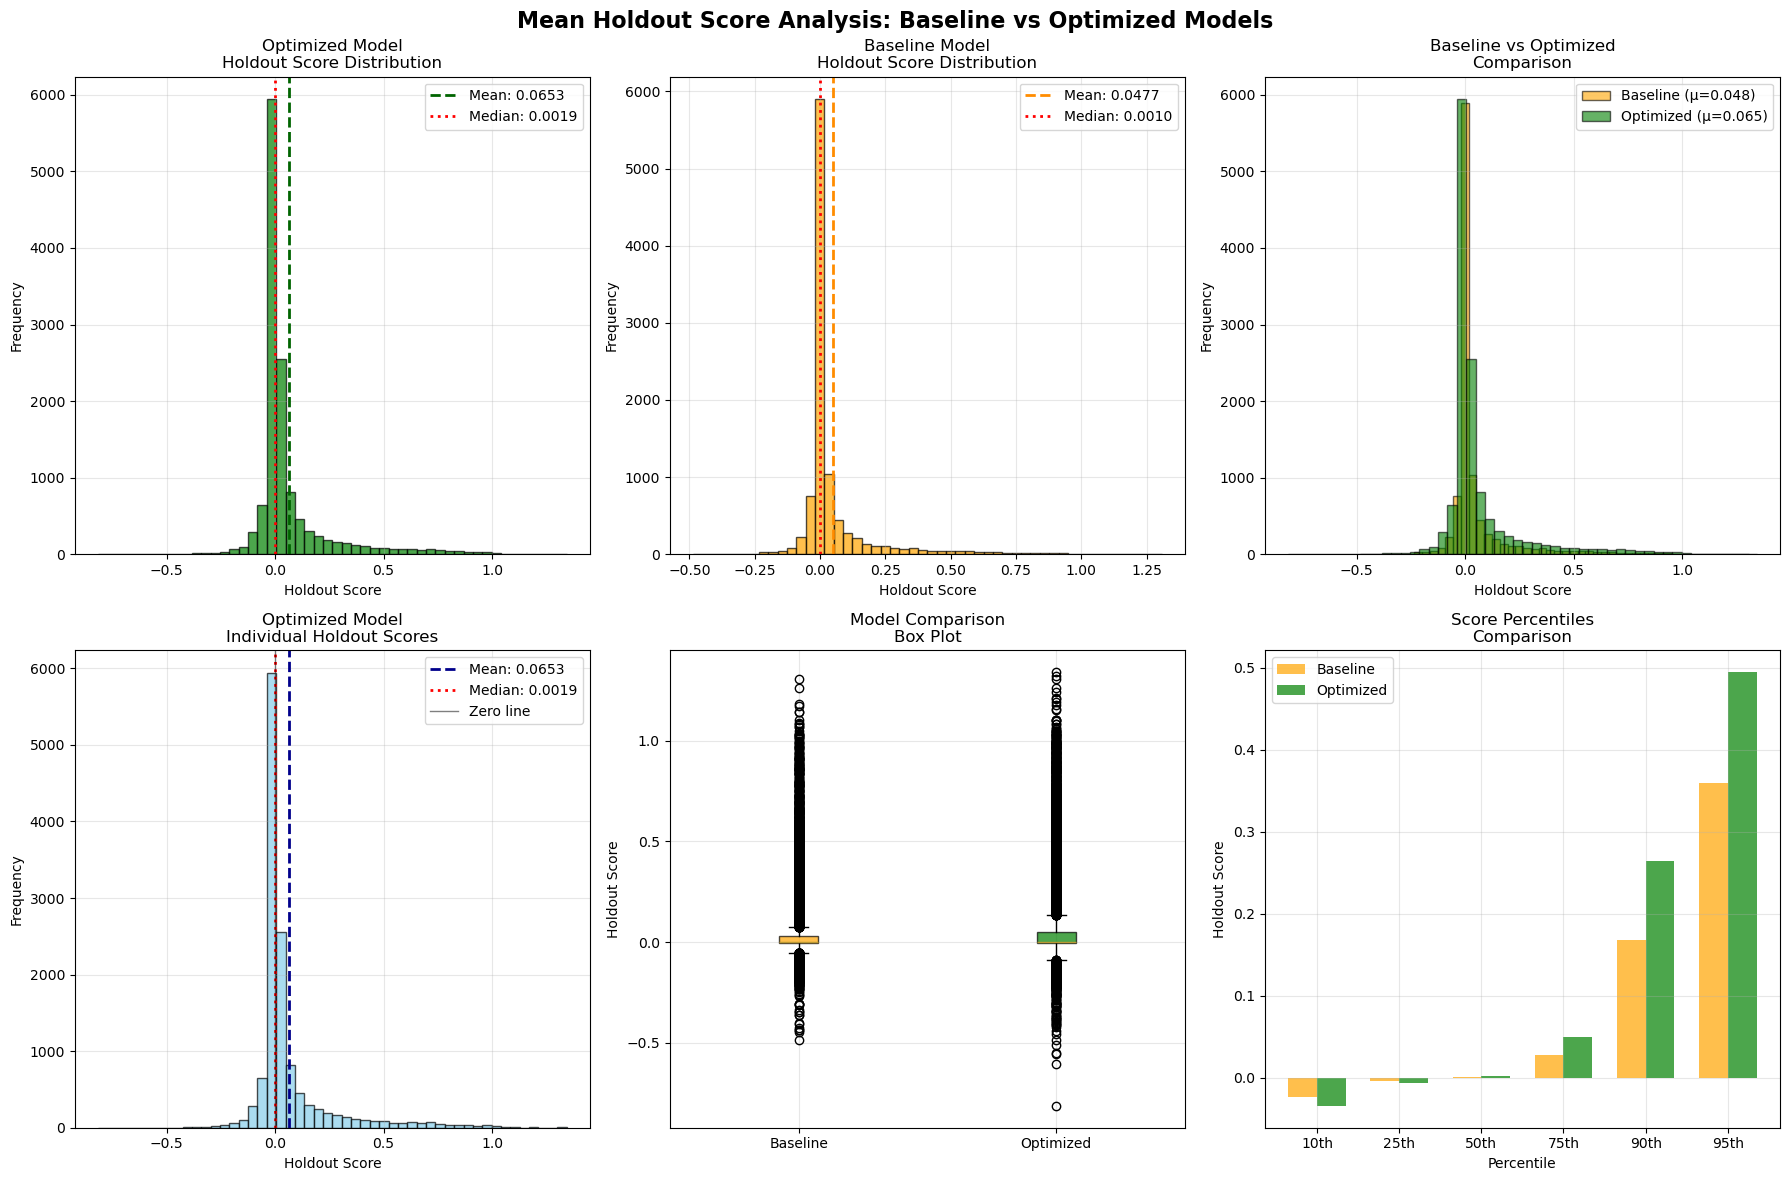


📈 HOLDOUT SCORE SUMMARY STATISTICS
    Model  Count   Mean  Median  Std Dev     Min    Max  25th Percentile  75th Percentile
 Baseline  10088 0.0477  0.0010   0.1528 -0.4855 1.3068          -0.0046           0.0278
Optimized  12974 0.0653  0.0019   0.1869 -0.8149 1.3429          -0.0064           0.0500

🎯 KEY INSIGHTS:
   Mean Score Improvement: +36.85%
   Absolute Improvement: +0.0176
   ✅ Hyperparameter optimization was successful!

💡 INTERPRETATION GUIDE:
   • Higher holdout scores = Better song preference prediction
   • Positive scores indicate above-average preference
   • The distribution shape shows model consistency
   • Compare mean improvements to assess optimization success


In [78]:
# 📊 COMPREHENSIVE MEAN HOLDOUT SCORE VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("📊 ANALYZING MEAN HOLDOUT SCORE DISTRIBUTIONS")
print("="*55)

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create a comprehensive figure with multiple subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Mean Holdout Score Analysis: Baseline vs Optimized Models', fontsize=16, fontweight='bold')

# =================================================================
# 1. INDIVIDUAL SCORE DISTRIBUTIONS
# =================================================================

# Subplot 1: Optimized Model Holdout Scores
if 'optimized_holdout_scores' in locals() and len(optimized_holdout_scores) > 0:
    axes[0, 0].hist(optimized_holdout_scores, bins=50, alpha=0.7, color='green', edgecolor='black')
    axes[0, 0].axvline(np.mean(optimized_holdout_scores), color='darkgreen', linestyle='--', linewidth=2, 
                      label=f'Mean: {np.mean(optimized_holdout_scores):.4f}')
    axes[0, 0].axvline(np.median(optimized_holdout_scores), color='red', linestyle=':', linewidth=2,
                      label=f'Median: {np.median(optimized_holdout_scores):.4f}')
    axes[0, 0].set_title('Optimized Model\nHoldout Score Distribution')
    axes[0, 0].set_xlabel('Holdout Score')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    print(f"✅ Optimized Model: {len(optimized_holdout_scores):,} holdout scores")
    print(f"   Mean: {np.mean(optimized_holdout_scores):.4f}")
    print(f"   Std:  {np.std(optimized_holdout_scores):.4f}")
else:
    axes[0, 0].text(0.5, 0.5, 'Optimized holdout\nscores not available', 
                   ha='center', va='center', transform=axes[0, 0].transAxes)
    axes[0, 0].set_title('Optimized Model\n(No Data)')

# Subplot 2: Baseline Model Holdout Scores
if 'baseline_holdout_scores' in locals() and len(baseline_holdout_scores) > 0:
    axes[0, 1].hist(baseline_holdout_scores, bins=50, alpha=0.7, color='orange', edgecolor='black')
    axes[0, 1].axvline(np.mean(baseline_holdout_scores), color='darkorange', linestyle='--', linewidth=2,
                      label=f'Mean: {np.mean(baseline_holdout_scores):.4f}')
    axes[0, 1].axvline(np.median(baseline_holdout_scores), color='red', linestyle=':', linewidth=2,
                      label=f'Median: {np.median(baseline_holdout_scores):.4f}')
    axes[0, 1].set_title('Baseline Model\nHoldout Score Distribution')
    axes[0, 1].set_xlabel('Holdout Score')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    print(f"✅ Baseline Model: {len(baseline_holdout_scores):,} holdout scores")
    print(f"   Mean: {np.mean(baseline_holdout_scores):.4f}")
    print(f"   Std:  {np.std(baseline_holdout_scores):.4f}")
else:
    axes[0, 1].text(0.5, 0.5, 'Baseline holdout\nscores not available', 
                   ha='center', va='center', transform=axes[0, 1].transAxes)
    axes[0, 1].set_title('Baseline Model\n(No Data)')

# =================================================================
# 2. COMPARISON VISUALIZATION
# =================================================================

# Subplot 3: Side-by-side comparison
if ('optimized_holdout_scores' in locals() and len(optimized_holdout_scores) > 0 and
    'baseline_holdout_scores' in locals() and len(baseline_holdout_scores) > 0):
    
    # Create overlaid histograms
    axes[0, 2].hist(baseline_holdout_scores, bins=50, alpha=0.6, color='orange', 
                   label=f'Baseline (μ={np.mean(baseline_holdout_scores):.3f})', edgecolor='black')
    axes[0, 2].hist(optimized_holdout_scores, bins=50, alpha=0.6, color='green', 
                   label=f'Optimized (μ={np.mean(optimized_holdout_scores):.3f})', edgecolor='black')
    axes[0, 2].set_title('Baseline vs Optimized\nComparison')
    axes[0, 2].set_xlabel('Holdout Score')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Calculate improvement
    improvement = ((np.mean(optimized_holdout_scores) - np.mean(baseline_holdout_scores)) / 
                  abs(np.mean(baseline_holdout_scores)) * 100)
    print(f"📈 Mean Score Improvement: {improvement:+.2f}%")
    
else:
    axes[0, 2].text(0.5, 0.5, 'Cannot compare:\nMissing data', 
                   ha='center', va='center', transform=axes[0, 2].transAxes)
    axes[0, 2].set_title('Comparison\n(Insufficient Data)')

# =================================================================
# 3. OPTIMIZED MODEL HOLDOUT SCORE DISTRIBUTION
# =================================================================

# Subplot 4: Individual Holdout Scores from Optimized Model
if 'optimized_holdout_scores' in locals() and len(optimized_holdout_scores) > 0:
    # Create histogram of individual holdout scores (includes negative values)
    axes[1, 0].hist(optimized_holdout_scores, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[1, 0].axvline(np.mean(optimized_holdout_scores), color='darkblue', linestyle='--', linewidth=2,
                      label=f'Mean: {np.mean(optimized_holdout_scores):.4f}')
    axes[1, 0].axvline(np.median(optimized_holdout_scores), color='red', linestyle=':', linewidth=2,
                      label=f'Median: {np.median(optimized_holdout_scores):.4f}')
    axes[1, 0].axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5,
                      label='Zero line')
    axes[1, 0].set_title('Optimized Model\nIndividual Holdout Scores')
    axes[1, 0].set_xlabel('Holdout Score')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Calculate statistics
    positive_scores = [s for s in optimized_holdout_scores if s > 0]
    negative_scores = [s for s in optimized_holdout_scores if s < 0]
    zero_scores = [s for s in optimized_holdout_scores if s == 0]
    
    print(f"📊 Individual Holdout Scores Distribution:")
    print(f"   Total scores: {len(optimized_holdout_scores):,}")
    print(f"   Positive scores: {len(positive_scores):,} ({len(positive_scores)/len(optimized_holdout_scores)*100:.1f}%)")
    print(f"   Negative scores: {len(negative_scores):,} ({len(negative_scores)/len(optimized_holdout_scores)*100:.1f}%)")
    print(f"   Zero scores: {len(zero_scores):,} ({len(zero_scores)/len(optimized_holdout_scores)*100:.1f}%)")
    print(f"   Range: {min(optimized_holdout_scores):.4f} to {max(optimized_holdout_scores):.4f}")
else:
    axes[1, 0].text(0.5, 0.5, 'Individual holdout\nscores not available', 
                   ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].set_title('Individual Scores\n(No Data)')


# =================================================================
# 4. BOX PLOT COMPARISON
# =================================================================

# Subplot 5: Box plot comparison
box_data = []
box_labels = []

if 'baseline_holdout_scores' in locals() and len(baseline_holdout_scores) > 0:
    box_data.append(baseline_holdout_scores)
    box_labels.append('Baseline')

if 'optimized_holdout_scores' in locals() and len(optimized_holdout_scores) > 0:
    box_data.append(optimized_holdout_scores)
    box_labels.append('Optimized')

if len(box_data) > 0:
    bp = axes[1, 1].boxplot(box_data, labels=box_labels, patch_artist=True)
    colors = ['orange', 'green']
    for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[1, 1].set_title('Model Comparison\nBox Plot')
    axes[1, 1].set_ylabel('Holdout Score')
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'No data available\nfor comparison', 
                   ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Box Plot\n(No Data)')

# =================================================================
# 5. SCORE PERCENTILES ANALYSIS
# =================================================================

# Subplot 6: Percentile comparison
if ('optimized_holdout_scores' in locals() and len(optimized_holdout_scores) > 0 and
    'baseline_holdout_scores' in locals() and len(baseline_holdout_scores) > 0):
    
    percentiles = [10, 25, 50, 75, 90, 95]
    baseline_percentiles = [np.percentile(baseline_holdout_scores, p) for p in percentiles]
    optimized_percentiles = [np.percentile(optimized_holdout_scores, p) for p in percentiles]
    
    x = np.arange(len(percentiles))
    width = 0.35
    
    axes[1, 2].bar(x - width/2, baseline_percentiles, width, label='Baseline', alpha=0.7, color='orange')
    axes[1, 2].bar(x + width/2, optimized_percentiles, width, label='Optimized', alpha=0.7, color='green')
    
    axes[1, 2].set_title('Score Percentiles\nComparison')
    axes[1, 2].set_xlabel('Percentile')
    axes[1, 2].set_ylabel('Holdout Score')
    axes[1, 2].set_xticks(x)
    axes[1, 2].set_xticklabels([f'{p}th' for p in percentiles])
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
else:
    axes[1, 2].text(0.5, 0.5, 'Cannot create\npercentile comparison', 
                   ha='center', va='center', transform=axes[1, 2].transAxes)
    axes[1, 2].set_title('Percentiles\n(Insufficient Data)')

plt.tight_layout()
plt.show()

# =================================================================
# 6. SUMMARY STATISTICS TABLE
# =================================================================

print(f"\n📈 HOLDOUT SCORE SUMMARY STATISTICS")
print("="*50)

summary_data = []

if 'baseline_holdout_scores' in locals() and len(baseline_holdout_scores) > 0:
    summary_data.append({
        'Model': 'Baseline',
        'Count': len(baseline_holdout_scores),
        'Mean': np.mean(baseline_holdout_scores),
        'Median': np.median(baseline_holdout_scores),
        'Std Dev': np.std(baseline_holdout_scores),
        'Min': np.min(baseline_holdout_scores),
        'Max': np.max(baseline_holdout_scores),
        '25th Percentile': np.percentile(baseline_holdout_scores, 25),
        '75th Percentile': np.percentile(baseline_holdout_scores, 75)
    })

if 'optimized_holdout_scores' in locals() and len(optimized_holdout_scores) > 0:
    summary_data.append({
        'Model': 'Optimized',
        'Count': len(optimized_holdout_scores),
        'Mean': np.mean(optimized_holdout_scores),
        'Median': np.median(optimized_holdout_scores),
        'Std Dev': np.std(optimized_holdout_scores),
        'Min': np.min(optimized_holdout_scores),
        'Max': np.max(optimized_holdout_scores),
        '25th Percentile': np.percentile(optimized_holdout_scores, 25),
        '75th Percentile': np.percentile(optimized_holdout_scores, 75)
    })

if summary_data:
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.round(4).to_string(index=False))
    
    # Calculate improvements if both models available
    if len(summary_data) == 2:
        baseline_mean = summary_data[0]['Mean']
        optimized_mean = summary_data[1]['Mean']
        improvement = ((optimized_mean - baseline_mean) / abs(baseline_mean)) * 100
        
        print(f"\n🎯 KEY INSIGHTS:")
        print(f"   Mean Score Improvement: {improvement:+.2f}%")
        print(f"   Absolute Improvement: {optimized_mean - baseline_mean:+.4f}")
        
        if improvement > 0:
            print(f"   ✅ Hyperparameter optimization was successful!")
        else:
            print(f"   ⚠️  Hyperparameter optimization showed minimal/negative improvement")
            
else:
    print("❌ No holdout score data available for summary")

print(f"\n💡 INTERPRETATION GUIDE:")
print(f"   • Higher holdout scores = Better song preference prediction")
print(f"   • Positive scores indicate above-average preference")
print(f"   • The distribution shape shows model consistency")
print(f"   • Compare mean improvements to assess optimization success")